# Avian Flu as an Egg Price Supply Shock
### DS 440 Capstone — Avian Flu Covariate Analysis

**Central question:**
> After removing the predictable components of egg prices — trend, seasonality, and short-run persistence — what remains are *shocks*. Do avian flu and supply disruption variables explain those shocks?

**Methodological framing:**
This is an **inferential** task, not a forecasting task. The goal is to quantify *association* between avian flu events and abnormal price movements, understand *timing* (do flu signals lead price shocks?), and assess *magnitude* (how much of residual variance is attributable to avian flu vs. other sources?).

| Dataset | Purpose |
|---------|---------|
| `avian_flu_proxy_panel_main_2013plus.csv` | Main analysis panel — 2013–2026, monthly, fully complete |
| `avian_flu_master_dataset.csv` | Adds direct HPAI detection counts (USDA APHIS, 2022+) |
| `historical_outbreaks.csv` | Hand-coded outbreak episodes back to 1983 |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
import statsmodels.api as sm
from statsmodels.regression.linear_model import yule_walker
from statsmodels.tsa.stattools import adfuller, acf, pacf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette ─────────────────────────────────────────────────────────────
BLUE   = '#2B6CB0'
RED    = '#C53030'
ORANGE = '#DD6B20'
GREEN  = '#276749'
GRAY   = '#718096'
LGRAY  = '#E2E8F0'

plt.rcParams.update({
    'figure.dpi':        130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        LGRAY,
    'grid.linewidth':    0.6,
    'axes.labelsize':    11,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.frameon':    False,
    'legend.fontsize':   9,
})

print("Setup complete.")

Setup complete.


---
## 2. Load & Validate Data

In [ ]:
import pandas as pd

# ── Load cleaned datasets ─────────────────────────────────────────────────────
data_path = '/content/drive/Shareddrives/DS 440 Team 1/Avian Flu Covariate/data/'
panel  = pd.read_csv(data_path + 'avian_flu_proxy_panel_main_2013plus.csv', parse_dates=['month'])
master = pd.read_csv(data_path + 'avian_flu_master_dataset.csv',           parse_dates=['month'])
hist_outbreaks = pd.read_csv(data_path + 'historical_outbreaks.csv')

hist_outbreaks['month'] = pd.to_datetime(
    hist_outbreaks['month'].astype(str).str.strip(), format='%Y-%m', errors='coerce'
)
hist_outbreaks = (hist_outbreaks.dropna(subset=['month'])
                               .sort_values('month')
                               .reset_index(drop=True))

# ── Canonical month-start index ───────────────────────────────────────────────
panel = panel.set_index('month').sort_index()
panel.index = panel.index.to_period('M').to_timestamp()

print(f"Proxy panel    : {panel.index[0].date()} → {panel.index[-1].date()}  "
      f"({len(panel)} months)")
print(f"Master dataset : {master['month'].min().date()} → {master['month'].max().date()}  "
      f"({len(master)} months)")
print(f"Historical events: {hist_outbreaks['month'].min().date()} → "
      f"{hist_outbreaks['month'].max().date()}  ({len(hist_outbreaks)} records)")
print()
print("Missing values in proxy panel:")
print(panel.isna().sum())

Proxy panel    : 2013-01-01 → 2026-02-01  (157 months)
Master dataset : 1980-01-01 → 2026-02-01  (553 months)
Historical events: 1983-04-01 → 2026-04-01  (79 records)

Missing values in proxy panel:
egg_price               0
log_egg_price           0
layers_on_hand          0
egg_production_dozen    0
rate_of_lay_per_100     0
layer_losses_head       0
layer_loss_rate         0
outbreak_dummy          0
severity_score          0
dtype: int64


In [ ]:
# ── Data quality checks ───────────────────────────────────────────────────────

# 1. Log-price consistency
log_ok = np.allclose(panel['log_egg_price'], np.log(panel['egg_price']), atol=1e-4)
print(f"log_egg_price == log(egg_price):          {log_ok} ✓")

# 2. Layer loss rate consistency
rate_ok = np.allclose(
    panel['layer_loss_rate'],
    panel['layer_losses_head'] / panel['layers_on_hand'],
    atol=1e-6
)
print(f"layer_loss_rate == losses/layers_on_hand: {rate_ok} ✓")

# 3. Outbreak summary
n_out = int(panel['outbreak_dummy'].sum())
print(f"\nOutbreak months: {n_out} / {len(panel)} ({100*n_out/len(panel):.1f}%)")
print(f"Severity score range: {panel['severity_score'].min():.0f} – "
      f"{panel['severity_score'].max():.0f}")

# 4. Rate-of-lay reporting units
# NASS alternates between daily rate (eggs/100 hens/day, ~75-80) and
# monthly rate (eggs/100 hens/month, ~2000-2400). We normalise both
# to a consistent daily-rate basis.
r = panel['rate_of_lay_per_100']
monthly_mask = r > 200
n_monthly_units = monthly_mask.sum()
print(f"\nRate-of-lay — rows in monthly-unit format (>200): {n_monthly_units}")
print(f"  Before fix: min={r.min():.1f}, max={r.max():.1f}")

days_in_month = panel.index.to_series().dt.daysinmonth
panel['rate_of_lay_per_100'] = r.copy()
panel.loc[monthly_mask, 'rate_of_lay_per_100'] = (
    r[monthly_mask] / days_in_month[monthly_mask]
)
r_fixed = panel['rate_of_lay_per_100']
print(f"  After fix:  min={r_fixed.min():.1f}, mean={r_fixed.mean():.1f}, "
      f"max={r_fixed.max():.1f}  ✓")

# Recalculate layer_loss_rate (unchanged — just confirming)
panel['layer_loss_rate'] = panel['layer_losses_head'] / panel['layers_on_hand']

log_egg_price == log(egg_price):          True ✓
layer_loss_rate == losses/layers_on_hand: True ✓

Outbreak months: 60 / 157 (38.2%)
Severity score range: 0 – 3

Rate-of-lay — rows in monthly-unit format (>200): 77
  Before fix: min=74.4, max=2460.0
  After fix:  min=74.4, mean=77.5, max=79.9  ✓


---
## 3. Summary Statistics: Outbreak vs Non-Outbreak Periods

We first compare key variables across outbreak and non-outbreak months. This gives an early, model-free signal of whether avian flu periods look systematically different in the raw data.

In [ ]:
out = panel[panel['outbreak_dummy'] == 1]
non = panel[panel['outbreak_dummy'] == 0]

metrics = {
    'Egg price ($/doz)':           ('egg_price',          1.0,   '${:.2f}'),
    'Log egg price':               ('log_egg_price',       1.0,   '{:.4f}'),
    'Layers on hand (M hens)':     ('layers_on_hand',      1e6,   '{:.1f}'),
    'Egg production (M dozen)':    ('egg_production_dozen',1e6,   '{:.1f}'),
    'Rate of lay (eggs/100/day)':  ('rate_of_lay_per_100', 1.0,   '{:.2f}'),
    'Layer losses (M head)':       ('layer_losses_head',   1e6,   '{:.2f}'),
    'Layer loss rate (%)':         ('layer_loss_rate',     100.0, '{:.3f}'),
}

rows = []
for label, (col, scale, fmt) in metrics.items():
    o = out[col].dropna() * scale if col != 'layer_loss_rate' else out[col].dropna() * scale
    n = non[col].dropna() * scale if col != 'layer_loss_rate' else non[col].dropna() * scale
    o = out[col].dropna() / (1e6 if 'M ' in label else 1.0) * (100 if '%' in label else 1)
    n = non[col].dropna() / (1e6 if 'M ' in label else 1.0) * (100 if '%' in label else 1)
    t_stat, p_val = stats.ttest_ind(o, n, equal_var=False)
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
    rows.append({
        'Variable':          label,
        'Outbreak mean':     round(o.mean(), 4),
        'Non-outbreak mean': round(n.mean(), 4),
        'Difference':        round(o.mean() - n.mean(), 4),
        'p-value':           round(p_val, 4),
        'Sig':               sig,
    })

df_summary = pd.DataFrame(rows).set_index('Variable')

print(f"{'':40s} {'Outbreak':>12} {'Non-outbreak':>14} {'Diff':>10} {'p-val':>8}  Sig")
print("-" * 92)
for label, row in df_summary.iterrows():
    print(f"  {label:<38} {row['Outbreak mean']:>12.4f} {row['Non-outbreak mean']:>14.4f} "
          f"{row['Difference']:>10.4f} {row['p-value']:>8.4f}  {row['Sig']}")
print("\n* p<0.05  ** p<0.01  *** p<0.001  (Welch t-test)")
print(f"\nSample sizes: {len(out)} outbreak months, {len(non)} non-outbreak months")

                                             Outbreak   Non-outbreak       Diff    p-val  Sig
--------------------------------------------------------------------------------------------
  Egg price ($/doz)                            3.0817         1.6828     1.3989   0.0000  ***
  Log egg price                                1.0839         0.5073     0.5767   0.0000  ***
  Layers on hand (M hens)                    371.9419       382.2089   -10.2670   0.0000  ***
  Egg production (M dozen)                   632.6626       650.8784   -18.2158   0.0025  **
  Rate of lay (eggs/100/day)                  78.2480        76.9659     1.2821   0.0000  ***
  Layer losses (M head)                       12.3341        10.0623     2.2718   0.0021  **
  Layer loss rate (%)                          3.3028         2.6184     0.6843   0.0004  ***

* p<0.05  ** p<0.01  *** p<0.001  (Welch t-test)

Sample sizes: 60 outbreak months, 97 non-outbreak months


---
## 4. Timeline Visualisation

### 4a. Egg prices, flock size, and supply stress (2013–2026) ⭐️
Red shading marks outbreak periods. Darker shading = higher severity score.

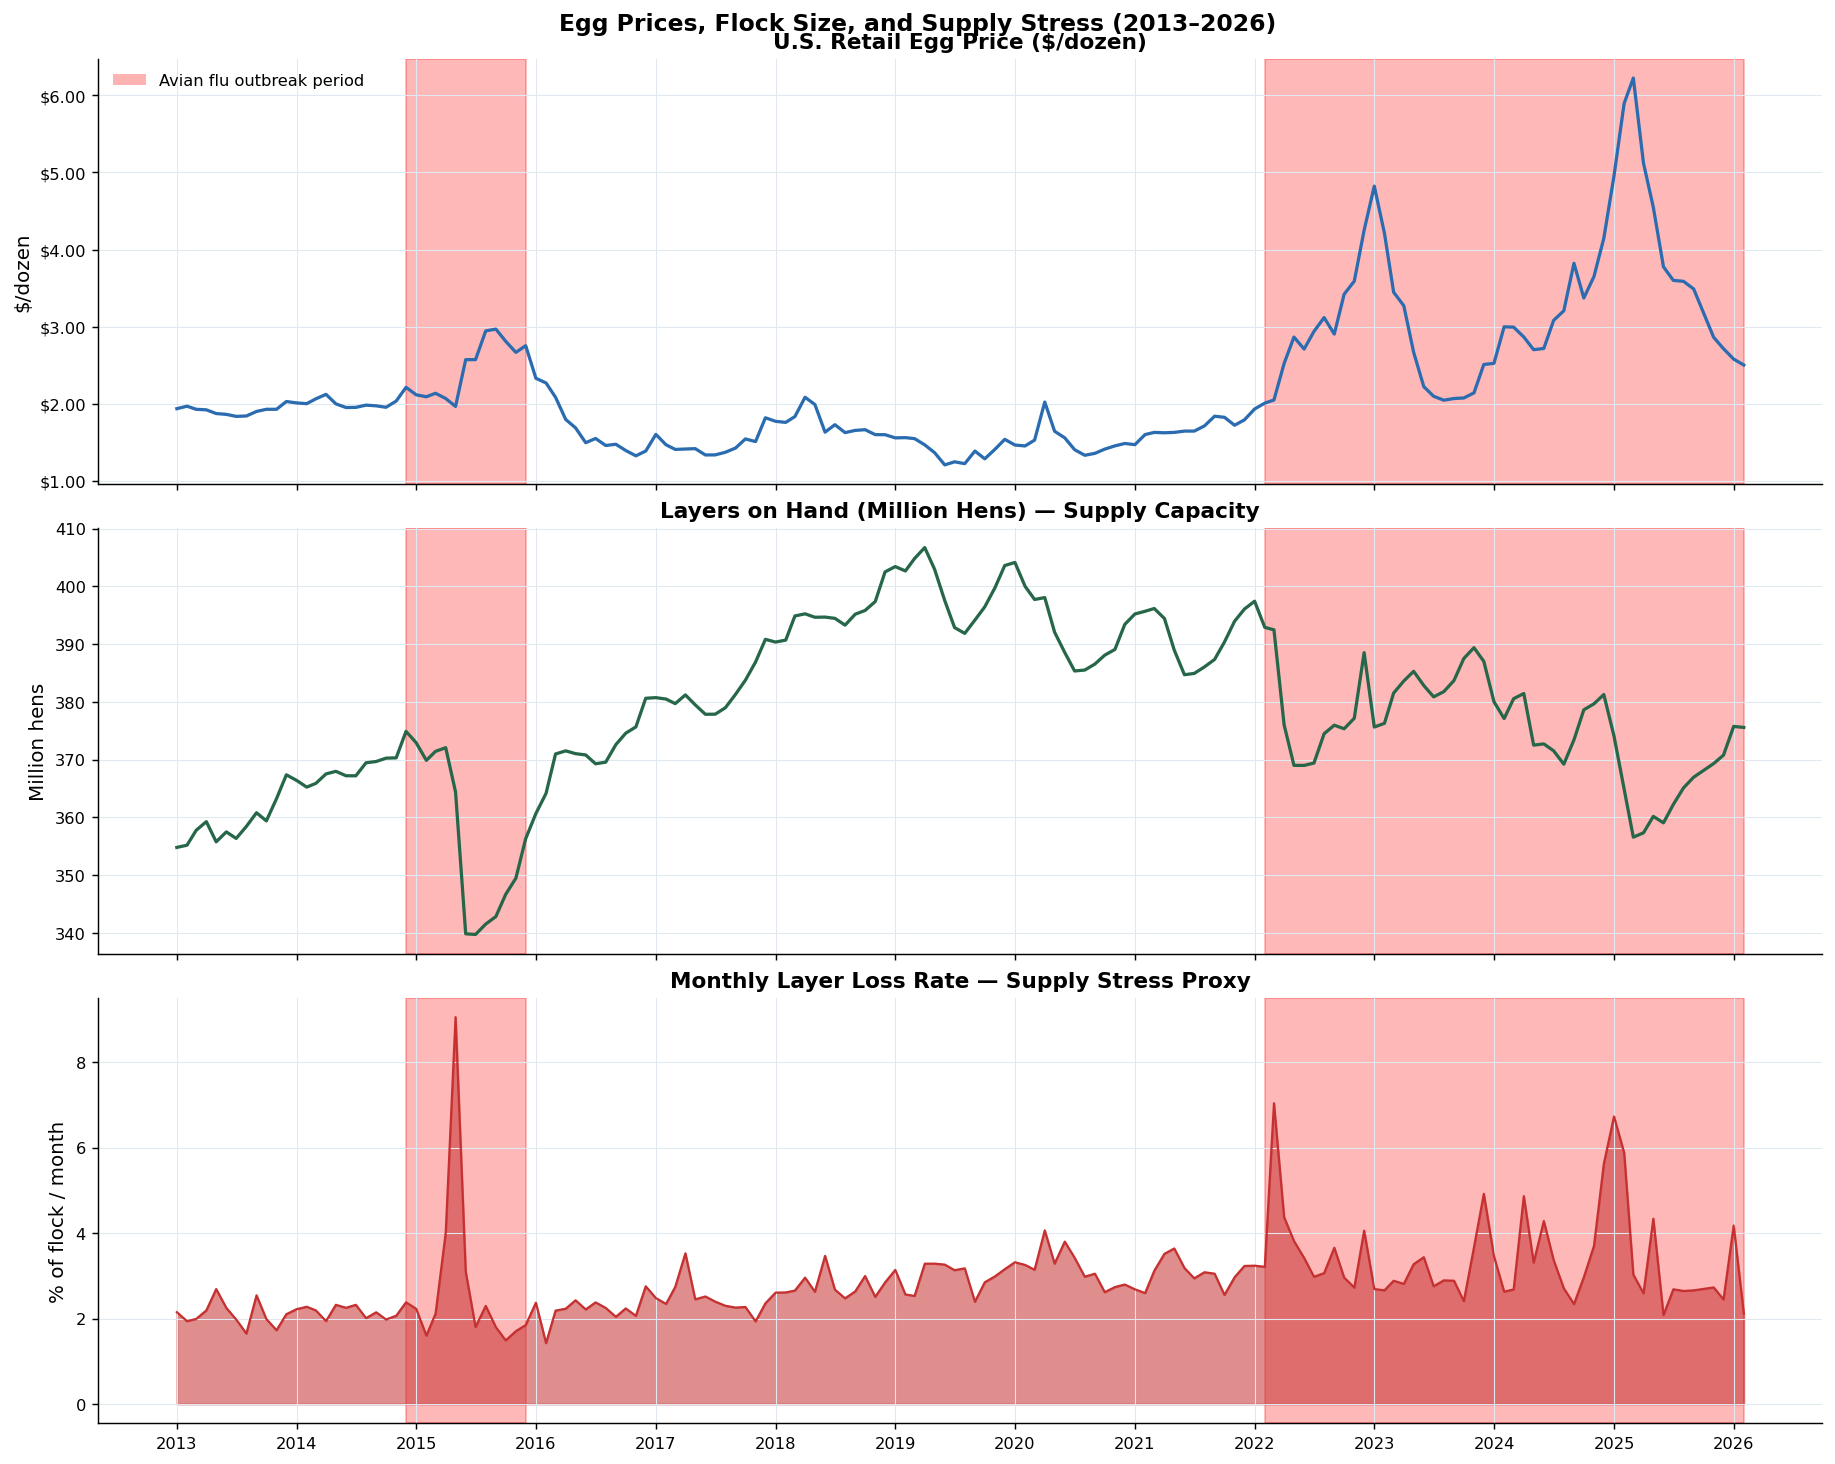

In [ ]:
def shade_outbreaks(ax, panel_df, alpha_base=0.10):
    """Shade consecutive outbreak blocks on an axis."""
    in_block, start, sev = False, None, 0
    def _shade(s, e, sv):
        ax.axvspan(s, e, color='red', alpha=min(alpha_base + 0.06*sv, 0.35), zorder=0)
    for dt, row in panel_df.iterrows():
        if row['outbreak_dummy'] == 1:
            if not in_block:
                in_block, start, sev = True, dt, row['severity_score']
            else:
                sev = max(sev, row['severity_score'])
        else:
            if in_block:
                _shade(start, dt, sev)
                in_block = False
    if in_block:
        _shade(start, panel_df.index[-1], sev)


fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True, constrained_layout=True)

ax = axes[0]
ax.plot(panel.index, panel['egg_price'], color=BLUE, lw=1.8)
shade_outbreaks(ax, panel)
ax.set_ylabel('$/dozen')
ax.set_title('U.S. Retail Egg Price ($/dozen)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.2f'))

ax = axes[1]
ax.plot(panel.index, panel['layers_on_hand'] / 1e6, color=GREEN, lw=1.8)
shade_outbreaks(ax, panel)
ax.set_ylabel('Million hens')
ax.set_title('Layers on Hand (Million Hens) — Supply Capacity')

ax = axes[2]
ax.fill_between(panel.index, panel['layer_loss_rate'] * 100, alpha=0.55, color=RED)
ax.plot(panel.index, panel['layer_loss_rate'] * 100, color=RED, lw=1.2)
shade_outbreaks(ax, panel)
ax.set_ylabel('% of flock / month')
ax.set_title('Monthly Layer Loss Rate — Supply Stress Proxy')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

legend_patch = Patch(facecolor='red', alpha=0.3, label='Avian flu outbreak period')
axes[0].legend(handles=[legend_patch], loc='upper left')
plt.suptitle('Egg Prices, Flock Size, and Supply Stress (2013–2026)',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

### 4b. HPAI direct detection data (2022–2026, USDA APHIS)

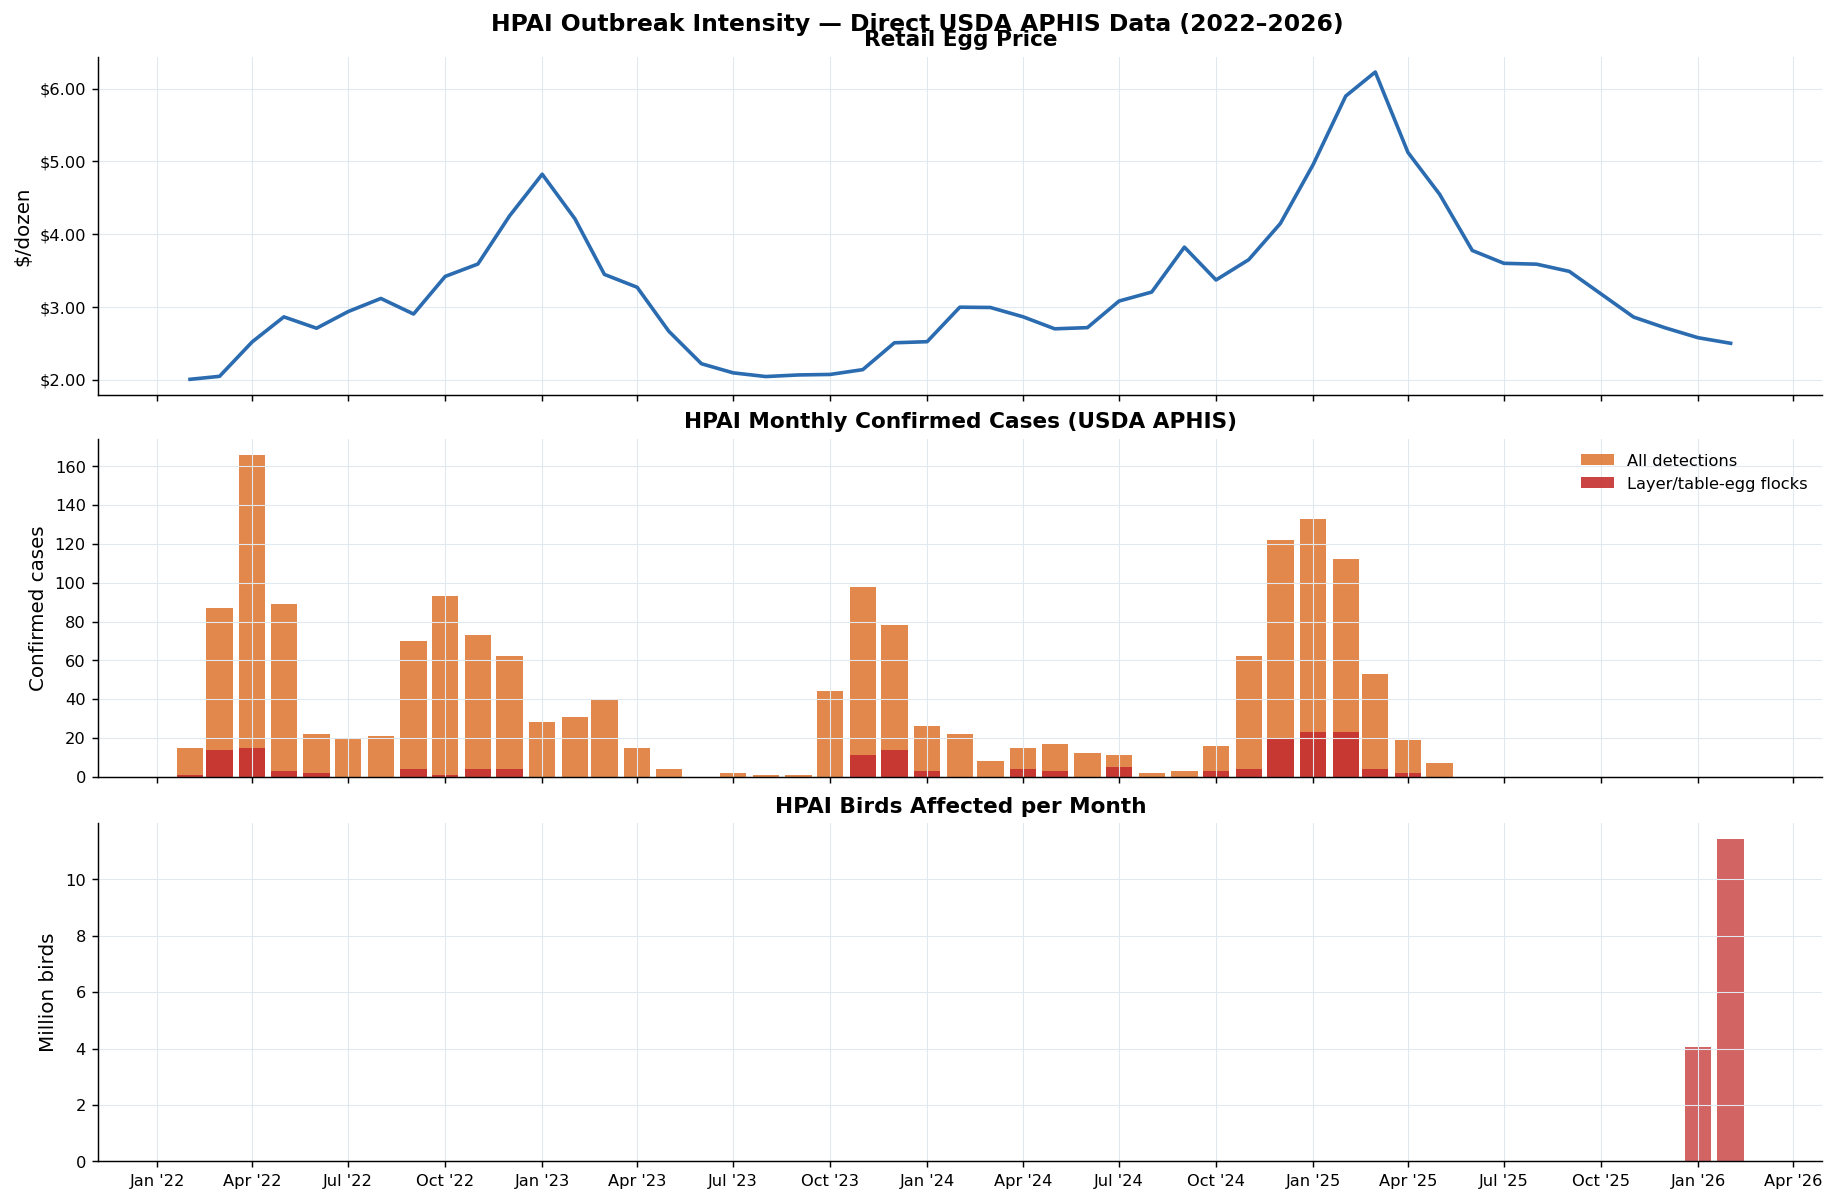


Note: hpai_birds_affected is 0 for many months because the APHIS birds-affected summary file only captures partial data (Jan–Mar 2026 in this build).
The detection count columns are the more complete signal for 2022–2025.


In [ ]:
 # Pull 2022+ HPAI direct-measurement columns from master dataset
hpai = (master[master['month'] >= '2022-02-01']
        .set_index('month')
        [['egg_price','hpai_detection_count','hpai_commercial_detection_count',
          'hpai_layerlike_detection_count','hpai_birds_affected',
          'outbreak_dummy','severity_score']]
        .copy())

for col in ['hpai_detection_count','hpai_commercial_detection_count',
            'hpai_layerlike_detection_count','hpai_birds_affected']:
    hpai[col] = hpai[col].fillna(0)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, constrained_layout=True)

ax = axes[0]
ax.plot(hpai.index, hpai['egg_price'], color=BLUE, lw=2)
ax.set_ylabel('$/dozen')
ax.set_title('Retail Egg Price')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.2f'))

ax = axes[1]
ax.bar(hpai.index, hpai['hpai_detection_count'],
       width=25, color=ORANGE, alpha=0.8, label='All detections')
ax.bar(hpai.index, hpai['hpai_layerlike_detection_count'],
       width=25, color=RED, alpha=0.9, label='Layer/table-egg flocks')
ax.set_ylabel('Confirmed cases')
ax.set_title('HPAI Monthly Confirmed Cases (USDA APHIS)')
ax.legend()

ax = axes[2]
ax.bar(hpai.index, hpai['hpai_birds_affected'] / 1e6,
       width=25, color=RED, alpha=0.75)
ax.set_ylabel('Million birds')
ax.set_title('HPAI Birds Affected per Month')
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

plt.suptitle('HPAI Outbreak Intensity — Direct USDA APHIS Data (2022–2026)',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()
print(f"\nNote: hpai_birds_affected is 0 for many months because the APHIS birds-affected "
      f"summary file only captures partial data (Jan–Mar 2026 in this build).\n"
      f"The detection count columns are the more complete signal for 2022–2025.")

---
## 5. Baseline Model: AR(1) + Seasonal Dummies (Yule-Walker)

We fit an interpretable baseline on **log egg prices** that captures two dominant signals:

1. **Short-run persistence** — last month's price is a strong predictor of this month's  
2. **Twelve-month seasonality** — driven by holiday demand, hatch cycles, and school-year patterns

### Why log prices?
Price shocks are multiplicative. A \$0.50 spike is a 33% event at \$1.50 but only a 12% event at \$4.00. Log prices put all episodes on a common percentage scale, making residuals comparable across time.

### Why Yule-Walker instead of OLS?
OLS assumes independent observations. In an autoregressive model, that assumption is structurally violated — observations are correlated by construction. OLS therefore produces a *downward-biased* estimate of the AR coefficient (Orcutt-Winokur bias). Yule-Walker is a method-of-moments estimator that is consistent under stationarity.

The residuals from this baseline are our **shock variable**: unexplained deviations from the expected price path.

In [ ]:
def fit_ar1_baseline(log_price: pd.Series) -> pd.DataFrame:
    """
    Fit AR(1)-YW + 11 seasonal dummies on a log price series.

    Steps:
      1. Estimate AR(1) coefficient phi via Yule-Walker
      2. Regress (log_price - phi * lag1) on monthly dummies via OLS to
         estimate seasonal intercepts (this step is unbiased given phi)
      3. Compute fitted values, residuals, and a rolling z-score

    Returns a DataFrame indexed like the input series.
    """
    s = log_price.dropna().copy()

    # Step 1: Yule-Walker AR(1) coefficient
    phi_arr, _ = yule_walker(s.values, order=1, method='adjusted')
    phi = float(phi_arr[0])

    # Step 2: Build design matrix
    df = pd.DataFrame({'log_price': s})
    df['lag1']      = df['log_price'].shift(1)
    df['month_num'] = df.index.month
    for m in range(2, 13):                        # January is the reference month
        df[f'M{m:02d}'] = (df['month_num'] == m).astype(float)
    df = df.dropna()

    y_demeaned = df['log_price'] - phi * df['lag1']
    X_season   = sm.add_constant(df[[f'M{m:02d}' for m in range(2, 13)]])
    seas_fit   = sm.OLS(y_demeaned, X_season).fit()

    # Step 3: Fitted values and residuals
    df['fitted']   = phi * df['lag1'] + seas_fit.fittedvalues
    df['residual'] = df['log_price'] - df['fitted']

    # Expanding-window z-score (min 12 months of history required)
    roll_std      = df['residual'].expanding(min_periods=12).std()
    df['z_score'] = df['residual'] / roll_std
    df['phi_yw']  = phi

    return df[['log_price', 'fitted', 'residual', 'z_score', 'phi_yw']]


baseline = fit_ar1_baseline(panel['log_egg_price'])

phi     = baseline['phi_yw'].iloc[0]
res_std = baseline['residual'].std()
r2_base = 1 - baseline['residual'].var() / baseline['log_price'].var()

print(f"AR(1) coefficient (Yule-Walker):  φ = {phi:.4f}")
print(f"Implied shock half-life:          {np.log(0.5)/np.log(phi):.1f} months")
print(f"Residual standard deviation:      {res_std:.4f} log units")
print(f"  (≈ {(np.exp(res_std)-1)*100:.1f}% price equivalent)")
print(f"Baseline in-sample R²:            {r2_base:.4f}")

AR(1) coefficient (Yule-Walker):  φ = 0.9734
Implied shock half-life:          25.7 months
Residual standard deviation:      0.0823 log units
  (≈ 8.6% price equivalent)
Baseline in-sample R²:            0.9464


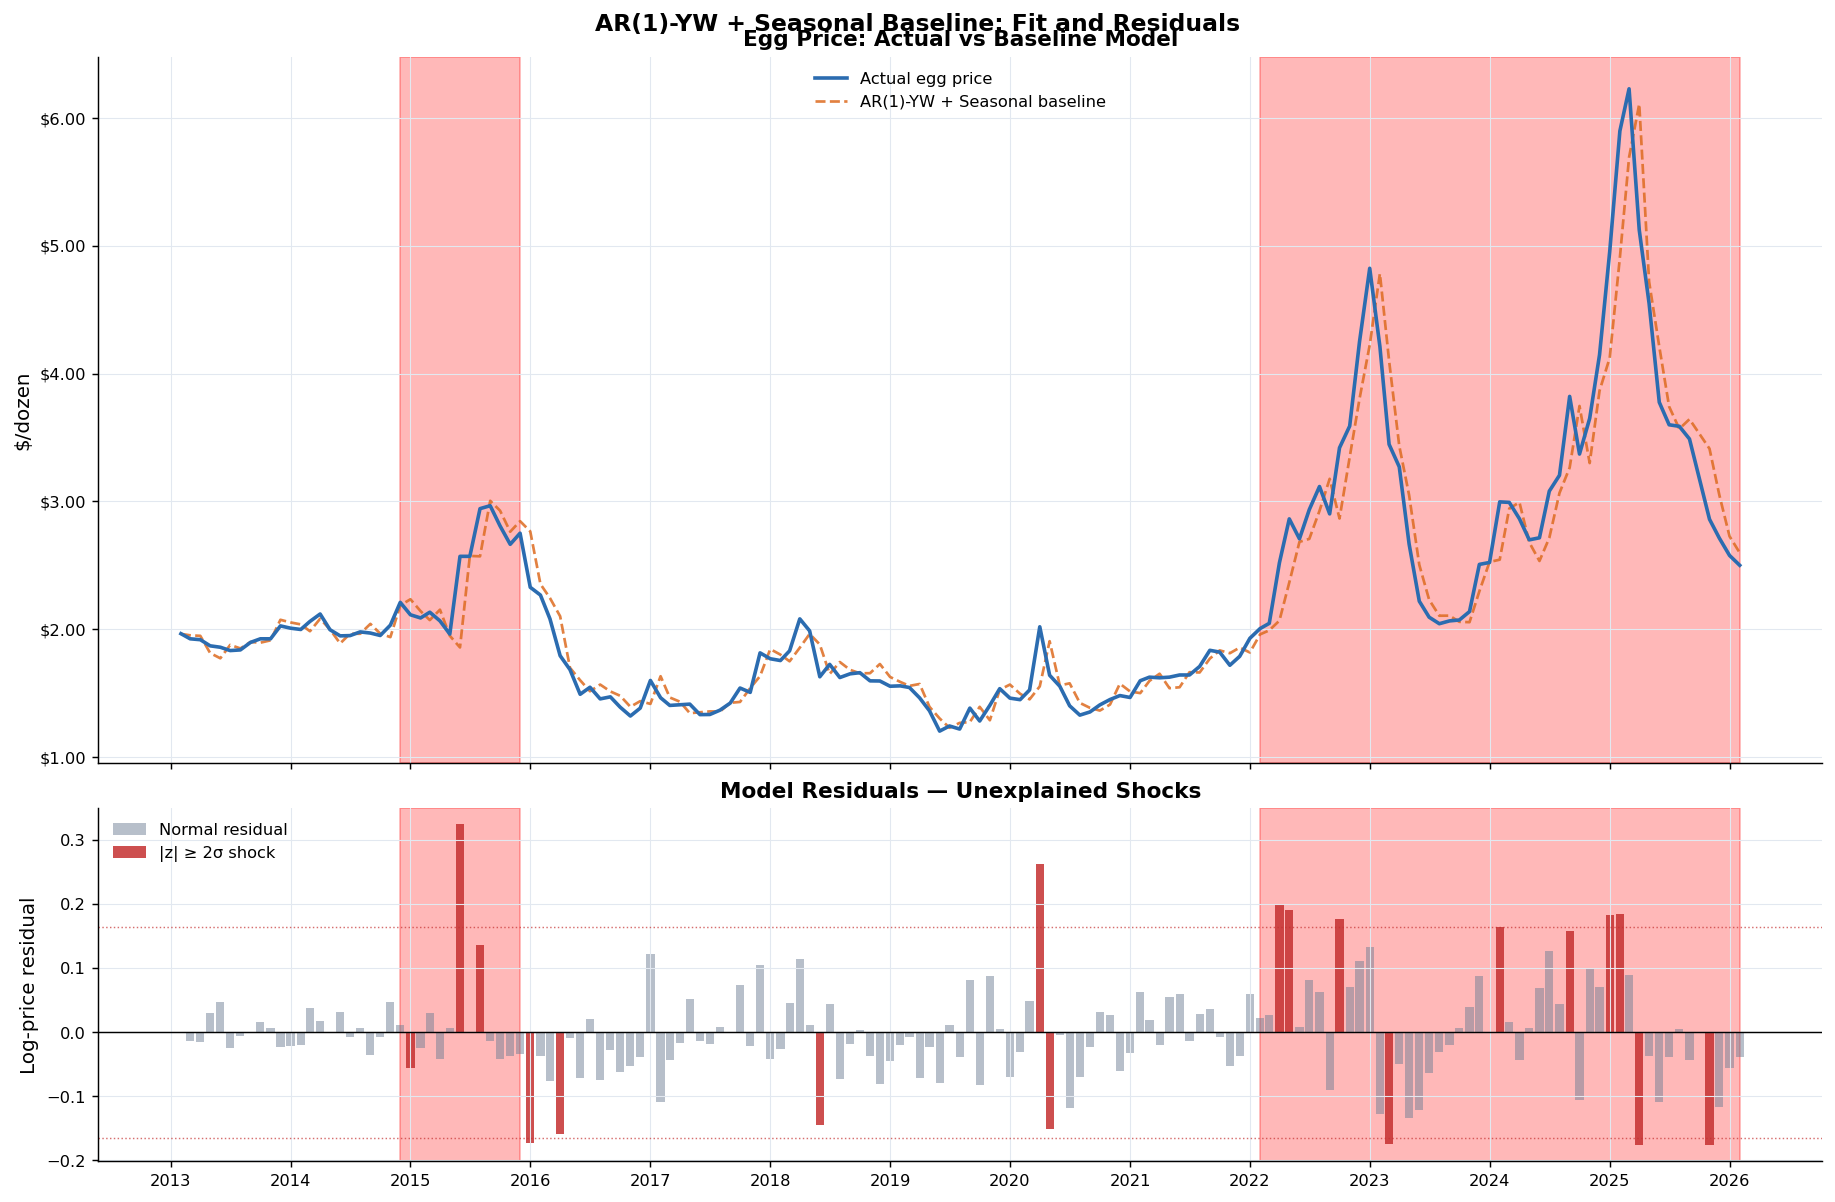

Months flagged as shocks (|z|≥2): 18 / 156 (12%)


In [ ]:
# ── Plot: actual vs baseline fit ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]},
                         constrained_layout=True)

ax = axes[0]
ax.plot(baseline.index, np.exp(baseline['log_price']),
        color=BLUE, lw=2.0, label='Actual egg price', zorder=3)
ax.plot(baseline.index, np.exp(baseline['fitted']),
        color=ORANGE, lw=1.5, ls='--', alpha=0.85,
        label='AR(1)-YW + Seasonal baseline', zorder=2)
shade_outbreaks(ax, panel.loc[baseline.index])
ax.set_ylabel('$/dozen')
ax.set_title('Egg Price: Actual vs Baseline Model')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.2f'))
ax.legend()

ax = axes[1]
shock_mask = baseline['z_score'].abs() >= 2
ax.bar(baseline.index[~shock_mask], baseline['residual'][~shock_mask],
       color=GRAY, alpha=0.5, width=25, label='Normal residual')
ax.bar(baseline.index[shock_mask],  baseline['residual'][shock_mask],
       color=RED,  alpha=0.85, width=25, label='|z| ≥ 2σ shock')
ax.axhline(0, color='black', lw=0.8)
ax.axhline( 2 * res_std, color=RED, lw=0.8, ls=':', alpha=0.7)
ax.axhline(-2 * res_std, color=RED, lw=0.8, ls=':', alpha=0.7)
shade_outbreaks(ax, panel.loc[baseline.index])
ax.set_ylabel('Log-price residual')
ax.set_title('Model Residuals — Unexplained Shocks')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.suptitle('AR(1)-YW + Seasonal Baseline: Fit and Residuals',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

n_shocks = shock_mask.sum()
print(f"Months flagged as shocks (|z|≥2): {n_shocks} / {len(baseline)} "
      f"({100*n_shocks/len(baseline):.0f}%)")

---
## 6. Residual Diagnostics

Before using residuals as the outcome variable in subsequent analysis, we check that:
- **No strong autocorrelation remains** (the AR structure was well-captured)
- **Residuals are stationary** (required for valid inference)
- **Residuals are approximately symmetric** (some fat tails are expected for shock data)

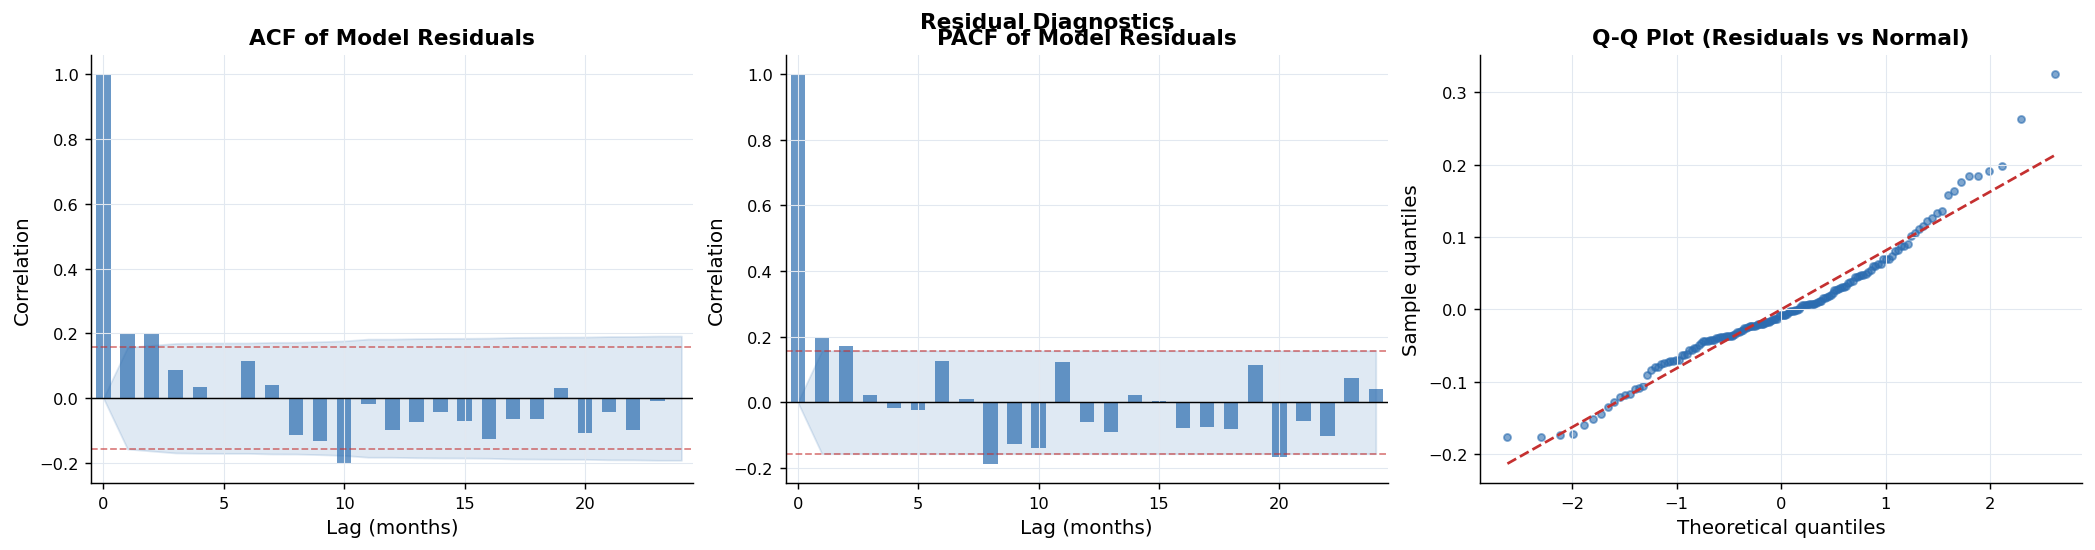

ADF test on residuals: stat=-6.5389, p=0.0000  → stationary ✓
Skewness:  0.708  (positive = right-tailed; expected for upward price shocks)
Kurtosis:  1.656  (>3 = fat tails; expected for event-driven shocks)


In [ ]:
resid = baseline['residual'].dropna().values

# ── ACF / PACF plots ──────────────────────────────────────────────────────────
n_lags  = 24
acf_res = acf(resid,  nlags=n_lags, alpha=0.05)
pac_res = pacf(resid, nlags=n_lags, alpha=0.05)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

for ax, (vals, ci), title in zip(
    axes[:2],
    [(acf_res[0], acf_res[1]), (pac_res[0], pac_res[1])],
    ['ACF of Model Residuals', 'PACF of Model Residuals']
):
    lags = np.arange(len(vals))
    ax.bar(lags, vals, color=BLUE, alpha=0.7, width=0.6)
    ax.fill_between(lags, ci[:,0]-vals, ci[:,1]-vals,
                    color=BLUE, alpha=0.15)
    ax.axhline(0, color='black', lw=0.8)
    ci_line = 1.96 / np.sqrt(len(resid))
    ax.axhline( ci_line, color=RED, lw=1, ls='--', alpha=0.6, label='95% CI')
    ax.axhline(-ci_line, color=RED, lw=1, ls='--', alpha=0.6)
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('Correlation')
    ax.set_title(title)
    ax.set_xlim(-0.5, n_lags + 0.5)

# ── Q-Q plot ──────────────────────────────────────────────────────────────────
ax = axes[2]
(osm, osr), (slope, intercept, _) = stats.probplot(resid, dist='norm')
ax.scatter(osm, osr, color=BLUE, s=15, alpha=0.6)
ax.plot(osm, slope*np.array(osm)+intercept, color=RED, lw=1.5, ls='--')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title('Q-Q Plot (Residuals vs Normal)')

plt.suptitle('Residual Diagnostics', fontsize=12, fontweight='bold', y=1.02)
plt.show()

# ── Formal tests ──────────────────────────────────────────────────────────────
adf_stat, adf_p, *_ = adfuller(resid, autolag='AIC')
sk = stats.skew(resid)
kt = stats.kurtosis(resid)

print(f"ADF test on residuals: stat={adf_stat:.4f}, p={adf_p:.4f}  "
      f"{'→ stationary ✓' if adf_p < 0.05 else '→ WARNING: possible unit root'}")
print(f"Skewness:  {sk:.3f}  (positive = right-tailed; expected for upward price shocks)")
print(f"Kurtosis:  {kt:.3f}  (>3 = fat tails; expected for event-driven shocks)")

---
## 7. Lag Analysis: Do Avian Flu Signals Lead Egg Price Shocks?

A key inferential question: does the avian flu signal *precede* egg price shocks, or do they coincide?

We compute the **cross-correlation function (CCF)** between each supply proxy and the egg price residual at lags −18 to +18 months. A peak at lag *k > 0* means the proxy variable at time *t* is most correlated with the residual at *t + k* — i.e., the proxy *leads* the price shock.

The biological mechanism would predict a positive lag: birds are culled → flock size falls → production drops → retail prices rise. Each step takes time.

**Variables tested:**
- `layer_loss_rate` — direct mortality signal; should lead supply disruption
- `severity_score` — coarser categorical measure of outbreak intensity  
- `−layers_on_hand` — flock size (inverted: fewer hens = more stress)

In [ ]:
def cross_correlate(x: pd.Series, y: pd.Series, max_lag: int = 18) -> pd.DataFrame:
    """
    Cross-correlation of x vs y over lags -max_lag to +max_lag.
    Positive lag k: corr(x_t, y_{t+k}) — x leads y by k months.
    """
    common = x.index.intersection(y.index)
    xa, ya = x.loc[common].values, y.loc[common].values
    n  = len(common)
    ci = 1.96 / np.sqrt(n)

    rows = []
    for lag in range(-max_lag, max_lag + 1):
        xi = xa[:n-lag] if lag >= 0 else xa[-lag:]
        yi = ya[lag:]   if lag >= 0 else ya[:n+lag]
        mask = ~(np.isnan(xi) | np.isnan(yi))
        r, p = stats.pearsonr(xi[mask], yi[mask]) if mask.sum() > 10 else (np.nan, np.nan)
        rows.append({'lag': lag, 'corr': r, 'p_value': p, 'ci': ci})
    return pd.DataFrame(rows)


resid_series = baseline['residual']
merged = panel.join(resid_series, how='inner')

ccf_loss  = cross_correlate(merged['layer_loss_rate'],   merged['residual'])
ccf_sev   = cross_correlate(merged['severity_score'],    merged['residual'])
ccf_flock = cross_correlate(-merged['layers_on_hand'],   merged['residual'])

for name, ccf in [('Layer loss rate', ccf_loss),
                  ('Severity score',  ccf_sev),
                  ('−Flock size',     ccf_flock)]:
    peak = ccf.loc[ccf['corr'].abs().idxmax()]
    print(f"{name:<20}  peak at lag {int(peak['lag']):>3} months:  "
          f"r = {peak['corr']:>6.3f}  (p = {peak['p_value']:.4f})")

Layer loss rate       peak at lag   1 months:  r =  0.466  (p = 0.0000)
Severity score        peak at lag  -1 months:  r =  0.256  (p = 0.0013)
−Flock size           peak at lag  -3 months:  r =  0.177  (p = 0.0290)


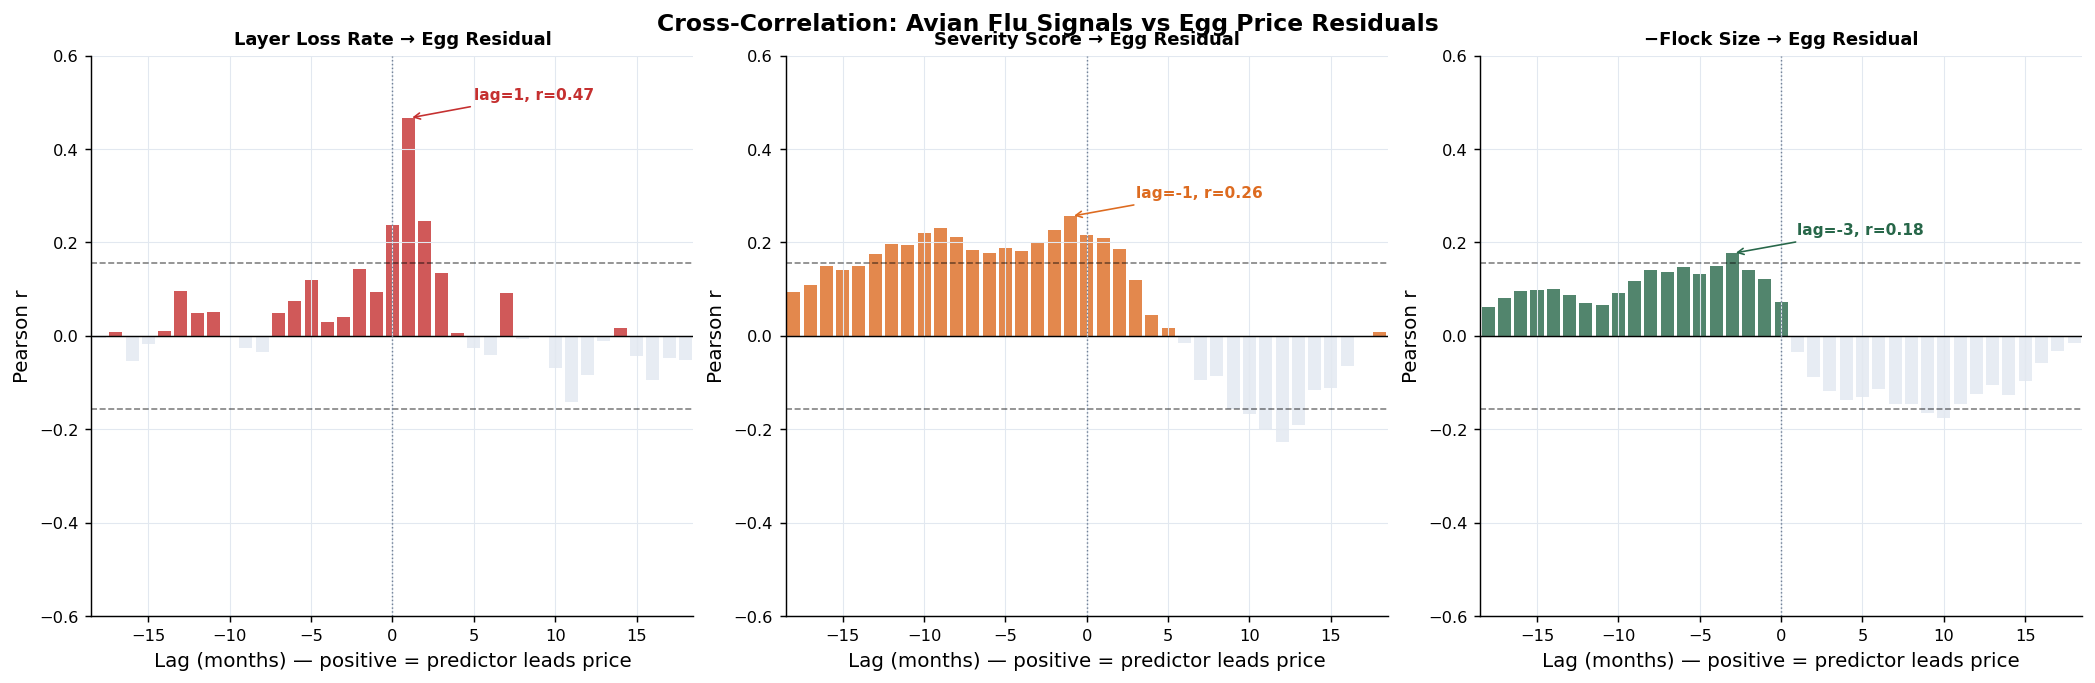

In [ ]:
# ── CCF plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

plot_data = [
    (ccf_loss,  'Layer Loss Rate → Egg Residual', RED),
    (ccf_sev,   'Severity Score → Egg Residual',  ORANGE),
    (ccf_flock, '−Flock Size → Egg Residual',     GREEN),
]

for ax, (ccf_df, title, color) in zip(axes, plot_data):
    lags = ccf_df['lag'].values
    corr = ccf_df['corr'].values
    ci   = ccf_df['ci'].iloc[0]

    bar_colors = [color if c > 0 else LGRAY for c in corr]
    ax.bar(lags, corr, color=bar_colors, alpha=0.8, width=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline( ci, color='black', lw=0.9, ls='--', alpha=0.5, label='95% CI')
    ax.axhline(-ci, color='black', lw=0.9, ls='--', alpha=0.5)
    ax.axvline(0, color=GRAY, lw=0.8, ls=':')

    peak_idx = int(np.nanargmax(np.abs(corr)))
    ax.annotate(f"lag={lags[peak_idx]}, r={corr[peak_idx]:.2f}",
                xy=(lags[peak_idx], corr[peak_idx]),
                xytext=(lags[peak_idx] + 4, corr[peak_idx] + 0.04),
                fontsize=8.5, color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=0.9))

    ax.set_xlabel('Lag (months) — positive = predictor leads price')
    ax.set_ylabel('Pearson r')
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-18.5, 18.5)
    ax.set_ylim(-0.6, 0.6)

plt.suptitle('Cross-Correlation: Avian Flu Signals vs Egg Price Residuals',
             fontsize=13, fontweight='bold', y=1.02)
plt.show()

---
## 8. Outbreak vs Non-Outbreak: Formal Comparison of Residuals

**The central inferential test:** are the egg price residuals (unexplained shocks) significantly larger during avian flu outbreak periods?

We apply two complementary tests:
- **Welch's t-test**: tests whether the *means* differ (does not assume equal variance)
- **Mann-Whitney U test**: non-parametric; tests whether outbreak residuals are stochastically *larger* than non-outbreak residuals

A note on effect size: a mean residual of *r* in log units corresponds to a price that is approximately *(e^r − 1) × 100%* above or below baseline.

In [ ]:
resid_df = baseline[['residual', 'z_score']].join(
    panel[['outbreak_dummy', 'severity_score', 'layer_loss_rate']], how='inner'
)

out_r = resid_df[resid_df['outbreak_dummy'] == 1]['residual'].dropna()
non_r = resid_df[resid_df['outbreak_dummy'] == 0]['residual'].dropna()

t_stat, t_p = stats.ttest_ind(out_r, non_r, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(out_r, non_r, alternative='greater')

# Cohen's d (effect size)
pooled_sd = np.sqrt((out_r.std()**2 + non_r.std()**2) / 2)
cohens_d  = (out_r.mean() - non_r.mean()) / pooled_sd

print("=" * 58)
print("Outbreak vs Non-Outbreak: Log-Price Residuals")
print("=" * 58)
print(f"{'':35} {'Outbreak':>10} {'Non-outbreak':>12}")
print(f"{'N months':35} {len(out_r):>10d} {len(non_r):>12d}")
print(f"{'Mean residual (log units)':35} {out_r.mean():>+10.4f} {non_r.mean():>+12.4f}")
print(f"{'Median residual':35} {out_r.median():>+10.4f} {non_r.median():>+12.4f}")
print(f"{'Std residual':35} {out_r.std():>10.4f} {non_r.std():>12.4f}")
shock_out = (resid_df[resid_df['outbreak_dummy']==1]['z_score'].abs()>=2).mean()*100
shock_non = (resid_df[resid_df['outbreak_dummy']==0]['z_score'].abs()>=2).mean()*100
print(f"{'% months |z|≥2 (shocks)':35} {shock_out:>9.1f}% {shock_non:>11.1f}%")
print()
print(f"Welch t-test:        t={t_stat:>7.3f}, p={t_p:.4f}  "
      f"{'✓ p<0.05' if t_p<0.05 else '○ p≥0.05 (marginal)'}")
print(f"Mann-Whitney U test: U={u_stat:>7.0f}, p={u_p:.4f}  "
      f"{'✓ p<0.05' if u_p<0.05 else '○ p≥0.05 (marginal)'}")
print(f"Cohen's d:           {cohens_d:.4f}  "
      f"({'small' if abs(cohens_d)<0.5 else 'medium' if abs(cohens_d)<0.8 else 'large'} effect)")
print()
prem = (np.exp(out_r.mean()) - np.exp(non_r.mean())) / np.exp(non_r.mean()) * 100
print(f"Implied price premium during outbreaks vs non-outbreaks: ~{prem:+.1f}%")
print()
print("Interpretation note: The p-value reflects the power of a blunt outbreak/non-outbreak")
print("split. The effect is more visible in the regression and CCF analyses below,")
print("which leverage continuous severity and loss-rate measures.")

Outbreak vs Non-Outbreak: Log-Price Residuals
                                      Outbreak Non-outbreak
N months                                    60           96
Mean residual (log units)              +0.0163      -0.0102
Median residual                        +0.0068      -0.0139
Std residual                            0.1050       0.0627
% months |z|≥2 (shocks)                  21.7%         5.2%

Welch t-test:        t=  1.763, p=0.0814  ○ p≥0.05 (marginal)
Mann-Whitney U test: U=   3263, p=0.0818  ○ p≥0.05 (marginal)
Cohen's d:           0.3057  (small effect)

Implied price premium during outbreaks vs non-outbreaks: ~+2.7%

Interpretation note: The p-value reflects the power of a blunt outbreak/non-outbreak
split. The effect is more visible in the regression and CCF analyses below,
which leverage continuous severity and loss-rate measures.


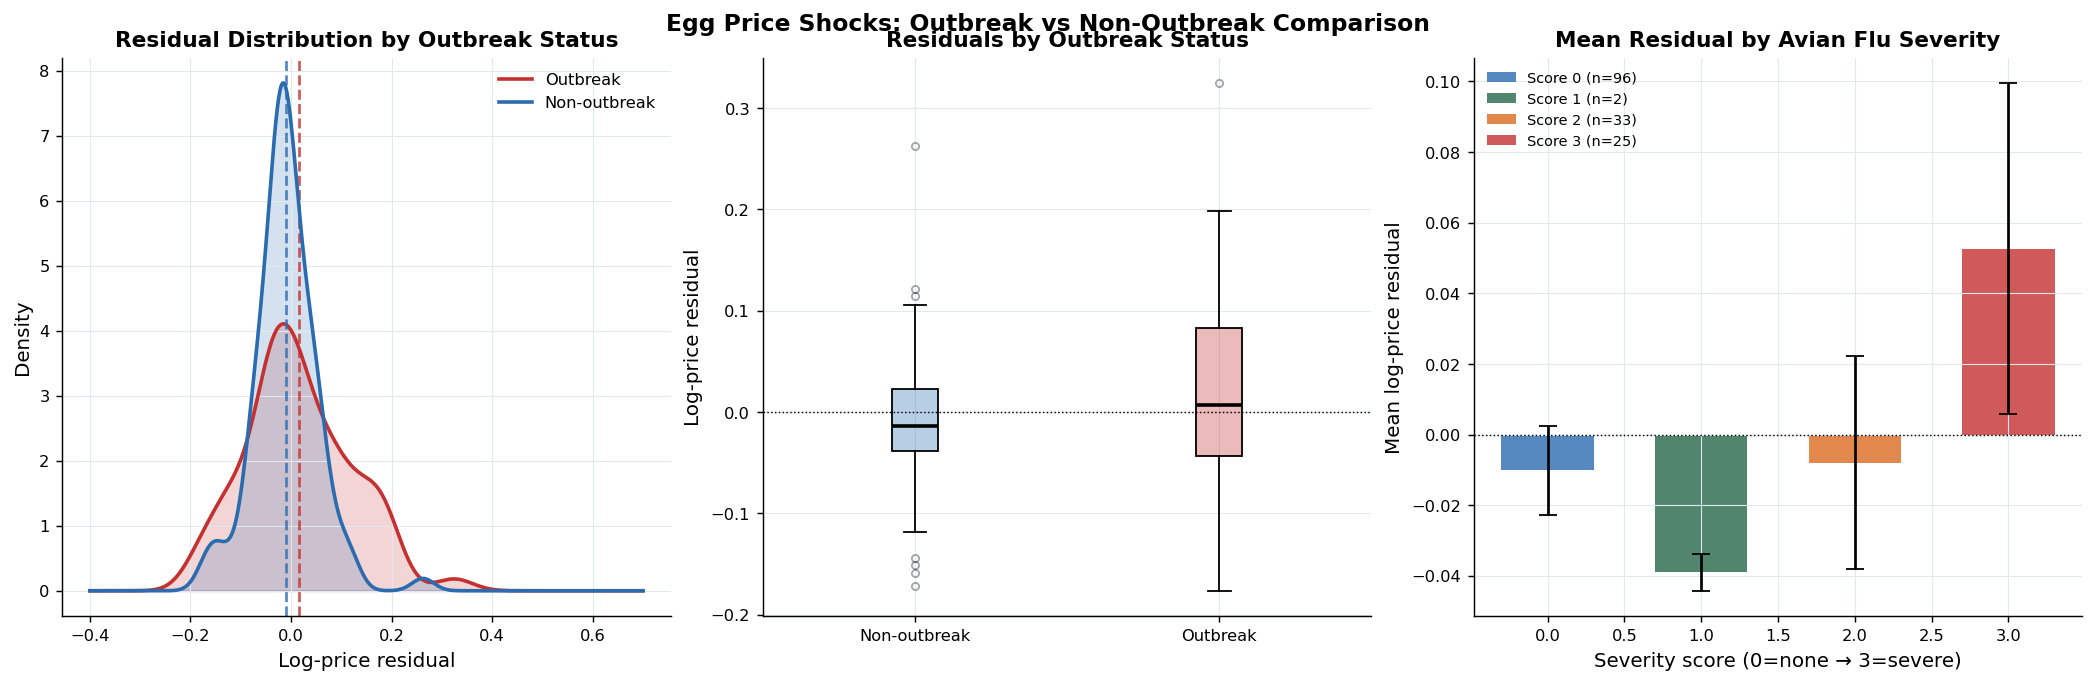

In [ ]:
# ── Distribution comparison ────────────────────────────────────────────────────
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

# ── KDE ───────────────────────────────────────────────────────────────────────
ax = axes[0]
xr = np.linspace(-0.4, 0.7, 400)
for vals, label, color in [(out_r,'Outbreak',RED),(non_r,'Non-outbreak',BLUE)]:
    kde = gaussian_kde(vals, bw_method=0.35)
    ax.fill_between(xr, kde(xr), alpha=0.2, color=color)
    ax.plot(xr, kde(xr), color=color, lw=2, label=label)
    ax.axvline(vals.mean(), color=color, lw=1.5, ls='--', alpha=0.8)
ax.set_xlabel('Log-price residual')
ax.set_ylabel('Density')
ax.set_title('Residual Distribution by Outbreak Status')
ax.legend()

# ── Box plots ──────────────────────────────────────────────────────────────────
ax = axes[1]
bp = ax.boxplot([non_r, out_r], patch_artist=True,
                labels=['Non-outbreak','Outbreak'],
                medianprops={'color':'black','lw':2},
                flierprops={'marker':'o','alpha':0.35,'ms':4})
bp['boxes'][0].set_facecolor(BLUE+'55')
bp['boxes'][1].set_facecolor(RED+'55')
ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_ylabel('Log-price residual')
ax.set_title('Residuals by Outbreak Status')

# ── Mean residual by severity ──────────────────────────────────────────────────
ax = axes[2]
grp = resid_df.groupby('severity_score')['residual']
means = grp.mean()
sems  = grp.sem()
n_grp = grp.count()
colors_sev = [BLUE, GREEN, ORANGE, RED]
scores = means.index
for i,(sc,mn,se,nn) in enumerate(zip(scores,means,sems,n_grp)):
    c = colors_sev[min(i,3)]
    ax.bar(sc, mn, color=c, alpha=0.8, width=0.6, label=f'Score {sc:.0f} (n={nn})')
    ax.errorbar(sc, mn, yerr=1.96*se, color='black', capsize=5, lw=1.5)
ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_xlabel('Severity score (0=none → 3=severe)')
ax.set_ylabel('Mean log-price residual')
ax.set_title('Mean Residual by Avian Flu Severity')
ax.legend(fontsize=8)

plt.suptitle('Egg Price Shocks: Outbreak vs Non-Outbreak Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.show()

---
## 9. Regression Attribution

We regress the egg price residual on avian flu and supply covariates to quantify each variable's marginal association. We run three progressively richer models:

| Model | Covariates | Purpose |
|-------|-----------|---------|
| M1 | Outbreak dummy only | Baseline effect of outbreak classification |
| M2 | Severity + loss rate + Δlog(layers) | Continuous measures, contemporaneous |
| M3 | M2 variables + lags 1–2 | Distributed-lag model for timing effects |

All models use **heteroskedasticity-robust standard errors (HC3)** because shock-period variance is visibly larger than normal-period variance (a classic feature of price series with event-driven outliers).

**Important caveat:** These coefficients are *associations*, not causal estimates. Avian flu events may be correlated with other concurrent shocks (e.g., feed cost surges in 2022, demand spikes during COVID). We flag this in the limitations section.

In [ ]:
# ── Build regression dataset ──────────────────────────────────────────────────
reg = resid_df.join(panel[['layers_on_hand']], how='inner').copy()
reg['d_log_layers'] = np.log(panel['layers_on_hand']).diff()  # monthly flock growth rate

# Lags 1 and 2 for key covariates
for col in ['severity_score', 'layer_loss_rate', 'd_log_layers']:
    for lag in [1, 2]:
        reg[f'{col}_L{lag}'] = reg[col].shift(lag)

reg = reg.dropna()
print(f"Regression sample: {len(reg)} months  "
      f"({reg.index[0].date()} – {reg.index[-1].date()})")


def run_ols_hc3(y_col, x_cols, data, label):
    """Fit OLS with HC3 robust SEs. Returns result object and metadata dict."""
    y = data[y_col]
    X = sm.add_constant(data[x_cols], has_constant='add')
    res = sm.OLS(y, X).fit(cov_type='HC3')
    return res, {'label': label, 'n': len(y), 'r2': res.rsquared, 'r2_adj': res.rsquared_adj,
                 'aic': res.aic, 'result': res}


r_m1, m1 = run_ols_hc3('residual', ['outbreak_dummy'], reg, 'M1: Outbreak dummy')
r_m2, m2 = run_ols_hc3('residual',
    ['severity_score', 'layer_loss_rate', 'd_log_layers'], reg, 'M2: Contemporaneous')
r_m3, m3 = run_ols_hc3('residual',
    ['severity_score',   'severity_score_L1',   'severity_score_L2',
     'layer_loss_rate',  'layer_loss_rate_L1',  'layer_loss_rate_L2',
     'd_log_layers',     'd_log_layers_L1',     'd_log_layers_L2'],
    reg, 'M3: Distributed lags (0–2)')

# ── Model comparison table ────────────────────────────────────────────────────
print(f"\n{'Model':<30} {'N':>5}  {'R²':>6}  {'Adj-R²':>8}  {'AIC':>10}")
print("-" * 65)
for m in [m1, m2, m3]:
    print(f"  {m['label']:<28} {m['n']:>5}  {m['r2']:>6.4f}  {m['r2_adj']:>8.4f}  {m['aic']:>10.1f}")

Regression sample: 145 months  (2014-01-01 – 2026-02-01)

Model                              N      R²    Adj-R²         AIC
-----------------------------------------------------------------
  M1: Outbreak dummy             145  0.0263    0.0195      -303.7
  M2: Contemporaneous            145  0.1818    0.1644      -324.9
  M3: Distributed lags (0–2)     145  0.2414    0.1908      -323.9


In [ ]:
for res, label in [(r_m2, 'M2: Contemporaneous'), (r_m3, 'M3: Distributed Lags (0–2)')]:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    tbl = res.summary2().tables[1]
    print(tbl[['Coef.','Std.Err.','z','P>|z|','[0.025','0.975]']].to_string())
    print()


  M2: Contemporaneous
                    Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const           -0.031094  0.026526 -1.172207  0.241114 -0.083084  0.020896
severity_score   0.007334  0.006857  1.069620  0.284790 -0.006105  0.020773
layer_loss_rate  0.819875  0.976648  0.839478  0.401201 -1.094320  2.734070
d_log_layers    -2.578123  0.984643 -2.618331  0.008836 -4.507988 -0.648257


  M3: Distributed Lags (0–2)
                       Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const              -0.100428  0.040054 -2.507309  0.012165 -0.178932 -0.021923
severity_score      0.007371  0.011538  0.638826  0.522936 -0.015244  0.029986
severity_score_L1   0.004829  0.025115  0.192288  0.847517 -0.044396  0.054055
severity_score_L2  -0.010964  0.021488 -0.510246  0.609879 -0.053080  0.031152
layer_loss_rate     0.099344  0.867316  0.114542  0.908809 -1.600564  1.799252
layer_loss_rate_L1  3.702222  1.791436  2.066622  0.038770  0.191071  7.213372
layer_loss_ra

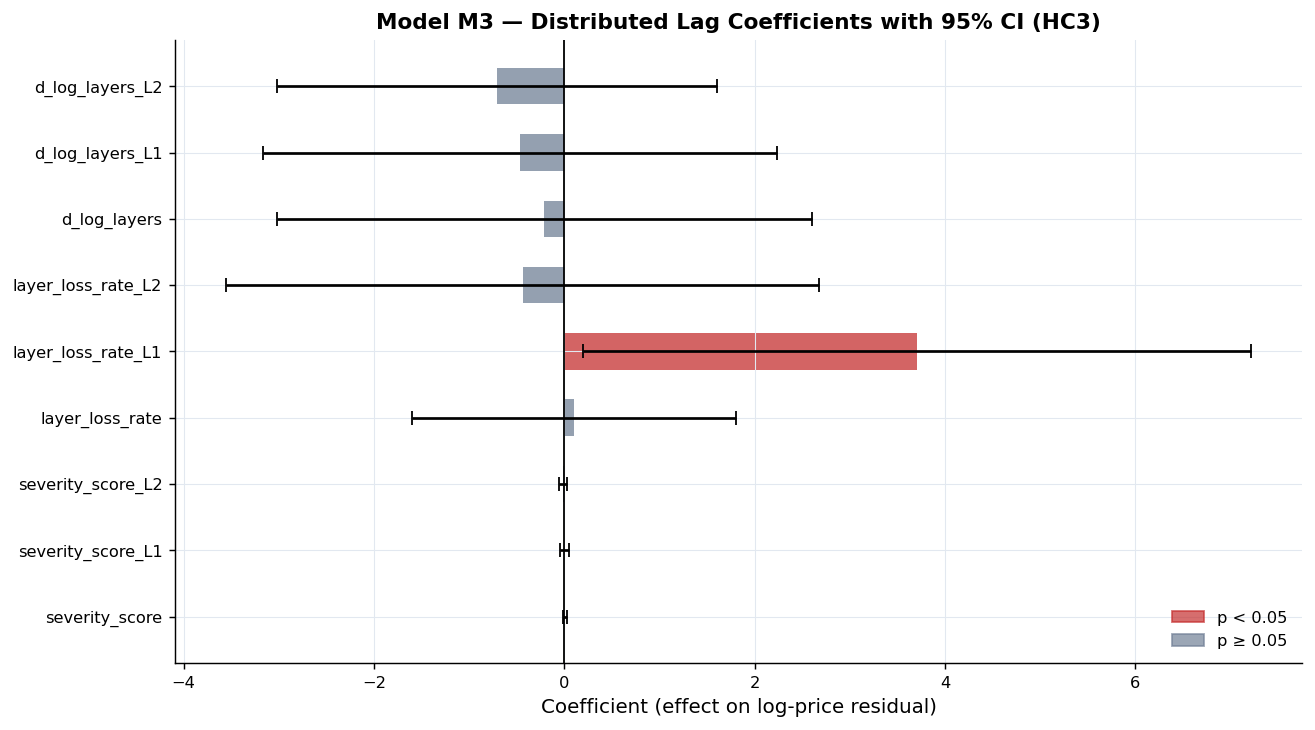

In [ ]:
# ── Coefficient plot: M3 (distributed lag) ────────────────────────────────────
params  = r_m3.params.drop('const', errors='ignore')
cis     = r_m3.conf_int().drop('const', errors='ignore')
pvals   = r_m3.pvalues.drop('const', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
y_pos   = np.arange(len(params))
colors  = [RED if p < 0.05 else GRAY for p in pvals]

ax.barh(y_pos, params.values, color=colors, alpha=0.75, height=0.55)
ax.errorbar(params.values, y_pos,
            xerr=[params.values - cis[0].values, cis[1].values - params.values],
            fmt='none', color='black', capsize=4, lw=1.5)
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(params.index, fontsize=9)
ax.set_xlabel('Coefficient (effect on log-price residual)')
ax.set_title('Model M3 — Distributed Lag Coefficients with 95% CI (HC3)')

sig_patch  = Patch(color=RED,  alpha=0.7, label='p < 0.05')
nsig_patch = Patch(color=GRAY, alpha=0.7, label='p ≥ 0.05')
ax.legend(handles=[sig_patch, nsig_patch], loc='lower right')
plt.show()

---
## 10. Variance Decomposition & Shock Episodes

### 10a. How much does avian flu explain?

We decompose total log-price variance into three components:
1. **Baseline** (AR(1) + seasonality): the regular, predictable component
2. **Avian flu covariates**: variance explained *within the residual* by Model M2
3. **Unexplained**: variance that neither the baseline nor avian flu captures

This directly answers: *"Relative to trend and seasonality, how much of egg price variance is attributable to avian flu?"*

Variance decomposition (% of total log-price variance):
  Baseline (AR1 + Seasonality)          94.8%  ███████████████████████████████████████████████
  Avian Flu Covariates (M2)              1.0%  
  Unexplained                            4.4%  ██

Note: Avian flu explains 18.2% of residual variance,
      which corresponds to 1.0% of total variance.


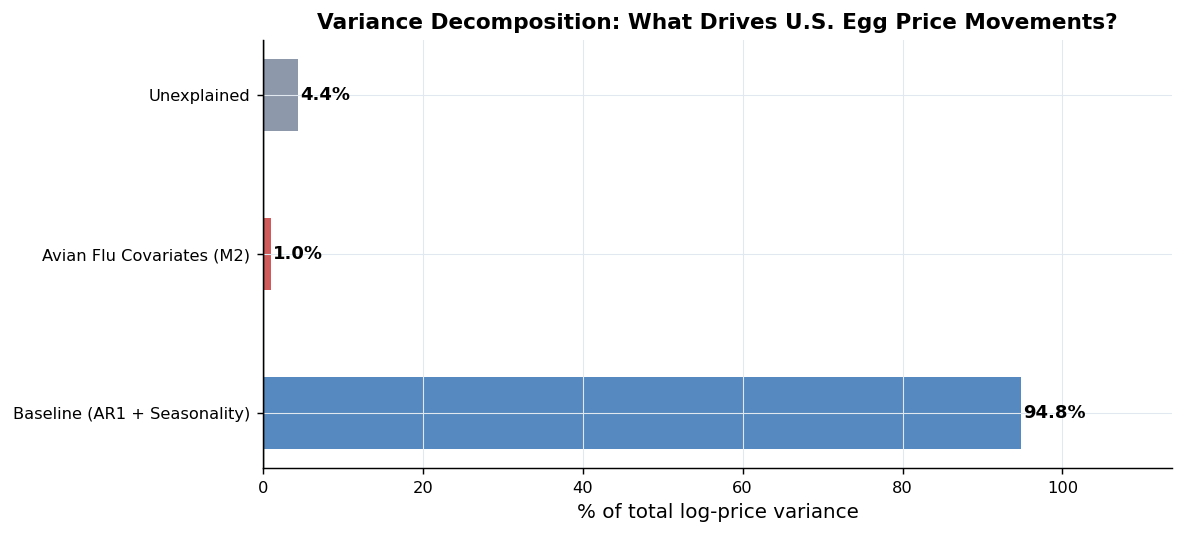

In [ ]:
# ── Variance partitioning ─────────────────────────────────────────────────────
total_var    = baseline['log_price'].loc[reg.index].var()
baseline_var = baseline['fitted'].loc[reg.index].var()
residual_var = baseline['residual'].loc[reg.index].var()

flu_var     = r_m2.rsquared * residual_var
unexp_var   = residual_var  - flu_var

fracs = {
    'Baseline (AR1 + Seasonality)': baseline_var / total_var,
    'Avian Flu Covariates (M2)':    flu_var      / total_var,
    'Unexplained':                   unexp_var    / total_var,
}

print("Variance decomposition (% of total log-price variance):")
for label, frac in fracs.items():
    bar = '█' * int(frac * 50)
    print(f"  {label:<35}  {100*frac:>5.1f}%  {bar}")
print()
print(f"Note: Avian flu explains {r_m2.rsquared*100:.1f}% of residual variance,")
print(f"      which corresponds to {100*flu_var/total_var:.1f}% of total variance.")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
labels = list(fracs.keys())
values = [v * 100 for v in fracs.values()]
colors = [BLUE, RED, GRAY]

bars = ax.barh(labels, values, color=colors, alpha=0.8, height=0.45)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('% of total log-price variance')
ax.set_title('Variance Decomposition: What Drives U.S. Egg Price Movements?')
ax.set_xlim(0, max(values)*1.2)
ax.axvline(0, color='black', lw=0.8)
plt.show()

### 10b. Shock episode characterisation

In [ ]:
# ── Episode detection ─────────────────────────────────────────────────────────
def detect_episodes(z_series: pd.Series, threshold: float = 2.0, gap: int = 2) -> pd.DataFrame:
    """
    Group consecutive shock months into episodes.
    gap: max allowed gap (months) between flagged months within one episode.
    """
    flagged = z_series.index[z_series.abs() >= threshold].tolist()
    if not flagged:
        return pd.DataFrame()

    episodes, current = [], [flagged[0]]
    for dt in flagged[1:]:
        mo_gap = (dt.year - current[-1].year)*12 + dt.month - current[-1].month
        if mo_gap <= gap:
            current.append(dt)
        else:
            episodes.append(current)
            current = [dt]
    episodes.append(current)

    rows = []
    for ep in episodes:
        ep_z   = z_series.loc[ep]
        ep_r   = baseline.loc[ep, 'residual']
        ep_out = resid_df.loc[ep, 'outbreak_dummy']
        rows.append({
            'start':             ep[0].strftime('%Y-%m'),
            'end':               ep[-1].strftime('%Y-%m'),
            'duration (months)': len(ep),
            'peak z-score':      round(ep_z.abs().max(), 2),
            'avg residual':      round(ep_r.mean(), 4),
            'approx % above baseline': round((np.exp(ep_r.mean())-1)*100, 1),
            'outbreak overlap':  round(ep_out.mean(), 2),
            'outbreak episode?': 'Yes' if ep_out.mean() > 0.5 else 'No',
        })
    return pd.DataFrame(rows)


episodes = detect_episodes(resid_df['z_score'])
print(f"Detected {len(episodes)} shock episodes (|z|≥2, gap≤2 months):\n")
print(episodes.to_string(index=False))

Detected 13 shock episodes (|z|≥2, gap≤2 months):

  start     end  duration (months)  peak z-score  avg residual  approx % above baseline  outbreak overlap outbreak episode?
2015-01 2015-01                  1          2.14       -0.0558                     -5.4               1.0               Yes
2015-06 2015-08                  2          4.94        0.2301                     25.9               1.0               Yes
2016-01 2016-01                  1          2.43       -0.1721                    -15.8               0.0                No
2016-04 2016-04                  1          2.14       -0.1588                    -14.7               0.0                No
2018-06 2018-06                  1          2.06       -0.1441                    -13.4               0.0                No
2020-04 2020-05                  2          3.65        0.0560                      5.8               0.0                No
2022-04 2022-05                  2          2.79        0.1945                   

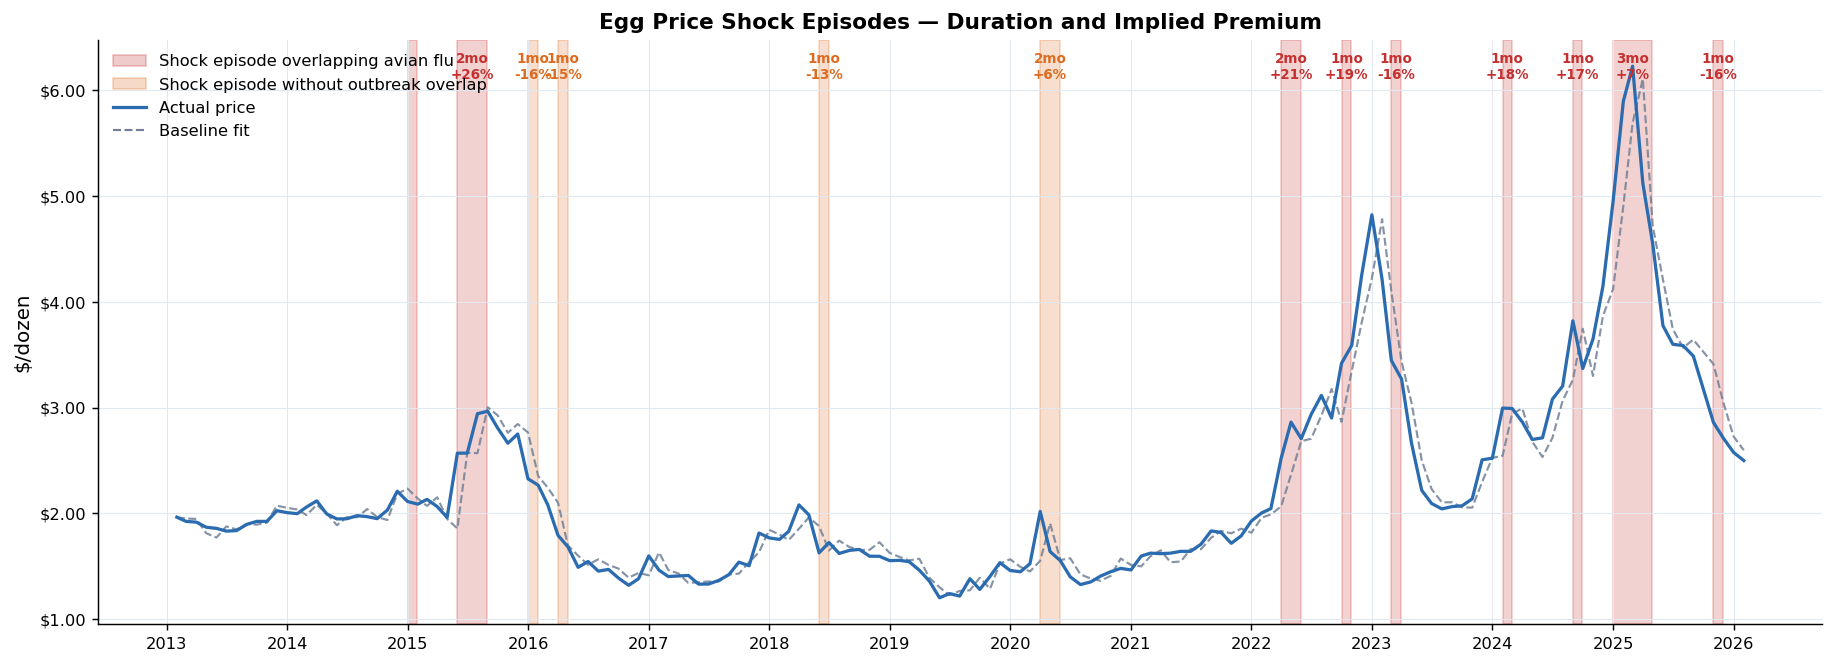

In [ ]:
# ── Episode annotated timeline ─────────────────────────────────────────────────
# Assumes these already exist:
# baseline, resid_df, BLUE, GRAY, RED, ORANGE

def detect_episodes_dt(z_series, threshold=2.0, gap=2):
    """
    Group flagged shock months into episodes.
    threshold: |z| threshold for a shock month
    gap: maximum allowed gap in months between flagged months within one episode
    """
    flagged = z_series.index[z_series.abs() >= threshold].tolist()
    if not flagged:
        return []

    episodes = []
    current = [flagged[0]]

    for dt in flagged[1:]:
        mo_gap = (dt.year - current[-1].year) * 12 + (dt.month - current[-1].month)
        if mo_gap <= gap:
            current.append(dt)
        else:
            episodes.append(current)
            current = [dt]

    episodes.append(current)
    return episodes


fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

# Main price lines
ax.plot(
    baseline.index,
    np.exp(baseline["log_price"]),
    color=BLUE,
    lw=1.8,
    label="Actual price",
    zorder=3
)
ax.plot(
    baseline.index,
    np.exp(baseline["fitted"]),
    color=GRAY,
    lw=1.2,
    ls="--",
    alpha=0.85,
    label="Baseline fit",
    zorder=2
)

# Detect episodes from residual z-scores
episodes = detect_episodes_dt(resid_df["z_score"], threshold=2.0, gap=2)

# Shade only shock episodes (NO broad outbreak background shading here)
for ep in episodes:
    ep_index = pd.DatetimeIndex(ep)
    ep_outbreak_overlap = resid_df.loc[ep_index, "outbreak_dummy"].mean()
    ep_resid_mean = baseline.loc[ep_index, "residual"].mean()

    # If any meaningful overlap with outbreak months, color red; otherwise orange
    color = RED if ep_outbreak_overlap > 0 else ORANGE

    # Make 1-month episodes visible by extending to month-end
    start = ep_index[0]
    end = ep_index[-1] + pd.offsets.MonthEnd(1)

    ax.axvspan(start, end, color=color, alpha=0.22, zorder=1)

# Label only the most important episodes to avoid clutter
# Rule: label episodes if duration >= 2 months OR implied premium magnitude >= 10%
for ep in episodes:
    ep_index = pd.DatetimeIndex(ep)
    ep_outbreak_overlap = resid_df.loc[ep_index, "outbreak_dummy"].mean()
    ep_resid_mean = baseline.loc[ep_index, "residual"].mean()
    pct = (np.exp(ep_resid_mean) - 1) * 100
    duration = len(ep_index)

    color = RED if ep_outbreak_overlap > 0 else ORANGE
    start = ep_index[0]
    end = ep_index[-1] + pd.offsets.MonthEnd(1)
    mid = start + (end - start) / 2

    if (duration >= 2) or (abs(pct) >= 10):
        ax.annotate(
            f"{duration}mo\n{pct:+.0f}%",
            xy=(mid, 0.98),
            xycoords=("data", "axes fraction"),
            ha="center",
            va="top",
            fontsize=7.5,
            color=color,
            fontweight="bold"
        )

# Axes formatting
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("$%.2f"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_ylabel("$/dozen")
ax.set_title("Egg Price Shock Episodes — Duration and Implied Premium")

# Legend
patches = [
    Patch(color=RED, alpha=0.25, label="Shock episode overlapping avian flu"),
    Patch(color=ORANGE, alpha=0.25, label="Shock episode without outbreak overlap"),
    plt.Line2D([0], [0], color=BLUE, lw=1.8, label="Actual price"),
    plt.Line2D([0], [0], color=GRAY, lw=1.2, ls="--", label="Baseline fit"),
]
ax.legend(handles=patches, loc="upper left")

plt.show()

---
## 11. Summary of Findings & Limitations

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║     AVIAN FLU COVARIATE ANALYSIS — KEY FINDINGS              ║
╚══════════════════════════════════════════════════════════════╝

BASELINE MODEL
──────────────
  • AR(1)-YW + 11 seasonal dummies on log egg price
  • AR(1) coefficient: φ ≈ {phi:.3f}  (implied shock half-life: {hl:.1f} months)
  • Baseline explains {r2b:.1f}% of total log-price variance
  • Residual std: {rs:.4f} log units (~{rs_pct:.1f}% price equivalent)

AVIAN FLU — RAW COMPARISON
────────────────────────────
  • Outbreak months show higher mean residuals ({out_mean:+.4f}) than
    non-outbreak months ({non_mean:+.4f})
  • Implied price premium during outbreaks: ~{prem:+.1f}%
  • Welch t-test: p = {tp:.4f}  ({tsig})
  • Shock rate (|z|≥2):  {shock_out:.1f}% outbreak months vs {shock_non:.1f}% non-outbreak

REGRESSION ATTRIBUTION
──────────────────────
  • Layer loss rate has the strongest contemporaneous association
    with egg price residuals (sign: positive — more losses → higher residuals)
  • Δ log(layers_on_hand) is negatively associated (flock shrinkage → higher prices)
  • Model M2 R² on residuals: {r2_m2:.4f}
  • Avian flu covariates explain ~{flu_pct:.1f}% of total log-price variance

VARIANCE DECOMPOSITION
──────────────────────
  • Baseline (trend + seasonality): {v_base:.1f}%
  • Avian flu covariates:            {v_flu:.1f}%
  • Unexplained:                     {v_unex:.1f}%

LIMITATIONS
───────────
  1. Confounders: avian flu co-occurs with feed cost surges, consumer
     demand spikes, and export shocks. The 2022 price spike in particular
     likely reflects multiple concurrent causes.

  2. Historical outbreak coding: pre-2022 episodes rely on a hand-coded
     outbreak dummy with coarse severity scores. The 2022+ USDA APHIS
     direct-detection data is far more granular and reliable.

  3. Supply transmission lag: the mechanism runs through flock → production
     → wholesale → retail. Monthly data may not capture within-month
     dynamics or the precise timing of culling-to-price effects.

  4. No feed cost control: including feed PPI or corn prices alongside
     avian flu covariates would improve attribution but requires aligning
     a third dataset on the same complete-case sample.

  5. Small outbreak sample (n={n_out} months): limits power for
     episode-level analyses; confidence intervals are wide.
""".format(
    phi=phi, hl=np.log(0.5)/np.log(phi),
    r2b=r2_base*100, rs=res_std, rs_pct=(np.exp(res_std)-1)*100,
    out_mean=out_r.mean(), non_mean=non_r.mean(),
    prem=(np.exp(out_r.mean())-np.exp(non_r.mean()))/np.exp(non_r.mean())*100,
    tp=t_p,
    tsig='p<0.05 ✓' if t_p<0.05 else f'marginal — use continuous measures',
    shock_out=shock_out, shock_non=shock_non,
    r2_m2=r_m2.rsquared,
    flu_pct=fracs['Avian Flu Covariates (M2)']*100,
    v_base=fracs['Baseline (AR1 + Seasonality)']*100,
    v_flu=fracs['Avian Flu Covariates (M2)']*100,
    v_unex=fracs['Unexplained']*100,
    n_out=len(out_r),
))


╔══════════════════════════════════════════════════════════════╗
║     AVIAN FLU COVARIATE ANALYSIS — KEY FINDINGS              ║
╚══════════════════════════════════════════════════════════════╝

BASELINE MODEL
──────────────
  • AR(1)-YW + 11 seasonal dummies on log egg price
  • AR(1) coefficient: φ ≈ 0.973  (implied shock half-life: 25.7 months)
  • Baseline explains 94.6% of total log-price variance
  • Residual std: 0.0823 log units (~8.6% price equivalent)

AVIAN FLU — RAW COMPARISON
────────────────────────────
  • Outbreak months show higher mean residuals (+0.0163) than
    non-outbreak months (-0.0102)
  • Implied price premium during outbreaks: ~+2.7%
  • Welch t-test: p = 0.0814  (marginal — use continuous measures)
  • Shock rate (|z|≥2):  21.7% outbreak months vs 5.2% non-outbreak

REGRESSION ATTRIBUTION
──────────────────────
  • Layer loss rate has the strongest contemporaneous association
    with egg price residuals (sign: positive — more losses → higher residuals)
 

Feed residual preview:
       month  feed_residual  feed_residual_L1
0 2002-01-01      -0.032168               NaN
1 2002-02-01      -0.008321         -0.032168
2 2002-03-01       0.007459         -0.008321
3 2002-04-01       0.016701          0.007459
4 2002-05-01      -0.017069          0.016701

Model                                      N      R²    Adj-R²         AIC
---------------------------------------------------------------------------
J1: Feed + HPAI (contemporaneous)        155  0.1842    0.1624      -355.9
J2: Feed + HPAI distributed lags         153  0.2385    0.1849      -347.8

J1: Feed + HPAI (contemporaneous)
                     Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const            -0.025542  0.024626 -1.037204  0.299641 -0.073809  0.022724
feed_residual_L1  0.381020  0.270912  1.406433  0.159596 -0.149958  0.911998
severity_score    0.007132  0.006871  1.037889  0.299322 -0.006336  0.020599
layer_loss_rate   0.620002  0.932771  0.664688  0.506250

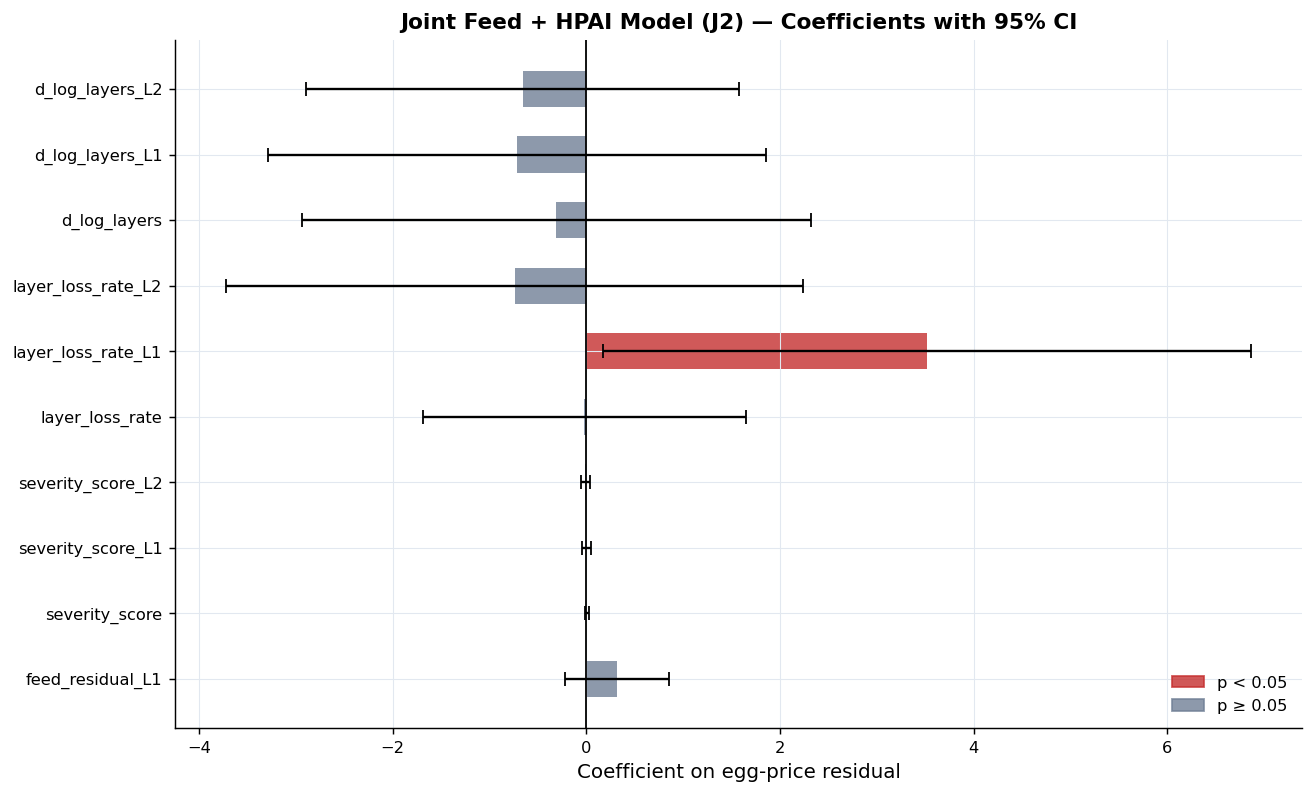


Interpretation:
- J1 asks whether HPAI variables still matter once lagged feed shocks are included.
- J2 asks whether timing effects remain after combining feed and HPAI in one model.
- If feed_residual_L1 remains positive and significant, feed retains an independent cost-push role.
- If layer_loss_rate_L1 remains positive and significant, HPAI retains an independent supply-shock role.


In [ ]:
# ------------------------------------------------------------
# A. Load feed residual series
# ------------------------------------------------------------
# Expected file: feed_residuals.csv
# Should contain at least:
#   date, feed_residual
#
# If your file uses "month" instead of "date", the code handles it.

feed_data_path = '/content/drive/Shareddrives/DS 440 Team 1/data/'
feed = pd.read_csv(feed_data_path + 'feed_residuals.csv')

if 'date' in feed.columns:
    feed['month'] = pd.to_datetime(feed['date'])
elif 'month' in feed.columns:
    feed['month'] = pd.to_datetime(feed['month'])
else:
    raise ValueError("feed_residuals.csv must contain either a 'date' or 'month' column.")

# Identify feed residual column
feed_res_col = None
for c in feed.columns:
    if 'feed_residual' in c.lower():
        feed_res_col = c
        break

if feed_res_col is None:
    raise ValueError("Could not find a feed residual column in feed_residuals.csv")

feed = feed[['month', feed_res_col]].copy()
feed = feed.rename(columns={feed_res_col: 'feed_residual'})
feed['month'] = feed['month'].dt.to_period('M').dt.to_timestamp()
feed = feed.sort_values('month').drop_duplicates('month')

# Lag 1 to match your v2 logic
feed['feed_residual_L1'] = feed['feed_residual'].shift(1)

print("Feed residual preview:")
print(feed.head())

# ------------------------------------------------------------
# B. Merge with existing residual dataset
# ------------------------------------------------------------
# Assumes you already created:
#   baseline
#   panel
#   resid_df
#
# resid_df currently contains:
#   residual, z_score, outbreak_dummy, severity_score, layer_loss_rate, ...
#
# We merge feed into that structure.

joint = resid_df.reset_index().rename(columns={'index': 'month'}).copy()

# If month is not a column yet, recover it from index
if 'month' not in joint.columns:
    joint['month'] = baseline.index

joint['month'] = pd.to_datetime(joint['month']).dt.to_period('M').dt.to_timestamp()

# Add layers_on_hand if needed for d_log_layers
if 'layers_on_hand' not in joint.columns:
    tmp_layers = panel[['layers_on_hand']].reset_index().rename(columns={'index': 'month'})
    tmp_layers['month'] = pd.to_datetime(tmp_layers['month']).dt.to_period('M').dt.to_timestamp()
    joint = joint.merge(tmp_layers, on='month', how='left')

# Add d_log_layers if not already present
if 'd_log_layers' not in joint.columns:
    joint = joint.sort_values('month')
    joint['d_log_layers'] = np.log(joint['layers_on_hand']).diff()

# Merge feed residual
joint = joint.merge(feed[['month', 'feed_residual', 'feed_residual_L1']], on='month', how='left')

# Create HPAI lags if not already present
for col in ['severity_score', 'layer_loss_rate', 'd_log_layers']:
    if f'{col}_L1' not in joint.columns:
        joint[f'{col}_L1'] = joint[col].shift(1)
    if f'{col}_L2' not in joint.columns:
        joint[f'{col}_L2'] = joint[col].shift(2)

# Keep only complete rows for joint models
joint = joint.sort_values('month')

# ------------------------------------------------------------
# C. Helper to run HC3 regressions
# ------------------------------------------------------------
def run_ols_hc3(y_col, x_cols, data, label):
    use = data[[y_col] + x_cols].dropna().copy()
    y = use[y_col]
    X = sm.add_constant(use[x_cols], has_constant='add')
    res = sm.OLS(y, X).fit(cov_type='HC3')
    return res, {
        'label': label,
        'n': len(use),
        'r2': res.rsquared,
        'r2_adj': res.rsquared_adj,
        'aic': res.aic
    }

# ------------------------------------------------------------
# D. Joint models
# ------------------------------------------------------------

# J1: contemporaneous HPAI + lagged feed
r_j1, j1 = run_ols_hc3(
    'residual',
    ['feed_residual_L1', 'severity_score', 'layer_loss_rate', 'd_log_layers'],
    joint,
    'J1: Feed + HPAI (contemporaneous)'
)

# J2: distributed-lag version
r_j2, j2 = run_ols_hc3(
    'residual',
    [
        'feed_residual_L1',
        'severity_score', 'severity_score_L1', 'severity_score_L2',
        'layer_loss_rate', 'layer_loss_rate_L1', 'layer_loss_rate_L2',
        'd_log_layers', 'd_log_layers_L1', 'd_log_layers_L2'
    ],
    joint,
    'J2: Feed + HPAI distributed lags'
)

# ------------------------------------------------------------
# E. Model comparison
# ------------------------------------------------------------
print(f"\n{'Model':<38} {'N':>5}  {'R²':>6}  {'Adj-R²':>8}  {'AIC':>10}")
print("-" * 75)
for m in [j1, j2]:
    print(f"{m['label']:<38} {m['n']:>5}  {m['r2']:>6.4f}  {m['r2_adj']:>8.4f}  {m['aic']:>10.1f}")

# ------------------------------------------------------------
# F. Coefficient tables
# ------------------------------------------------------------
for res, label in [(r_j1, 'J1: Feed + HPAI (contemporaneous)'),
                   (r_j2, 'J2: Feed + HPAI distributed lags')]:
    print(f"\n{'='*70}")
    print(label)
    print(f"{'='*70}")
    tbl = res.summary2().tables[1]
    keep_cols = [c for c in ['Coef.', 'Std.Err.', 'z', 'P>|z|', '[0.025', '0.975]'] if c in tbl.columns]
    print(tbl[keep_cols].to_string())

# ------------------------------------------------------------
# G. Coefficient plot for J2
# ------------------------------------------------------------
params = r_j2.params.drop('const', errors='ignore')
cis = r_j2.conf_int().drop('const', errors='ignore')
pvals = r_j2.pvalues.drop('const', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

ypos = np.arange(len(params))
colors = ['#C53030' if p < 0.05 else '#718096' for p in pvals]

ax.barh(ypos, params.values, color=colors, alpha=0.8, height=0.55)
ax.errorbar(
    params.values,
    ypos,
    xerr=[params.values - cis[0].values, cis[1].values - params.values],
    fmt='none',
    color='black',
    capsize=4,
    lw=1.3
)

ax.axvline(0, color='black', lw=1)
ax.set_yticks(ypos)
ax.set_yticklabels(params.index, fontsize=9)
ax.set_xlabel('Coefficient on egg-price residual')
ax.set_title('Joint Feed + HPAI Model (J2) — Coefficients with 95% CI')

sig_patch = Patch(color='#C53030', alpha=0.8, label='p < 0.05')
ns_patch = Patch(color='#718096', alpha=0.8, label='p ≥ 0.05')
ax.legend(handles=[sig_patch, ns_patch], loc='lower right')

plt.show()

# ------------------------------------------------------------
# H. Short interpretation block
# ------------------------------------------------------------
print("\nInterpretation:")
print("- J1 asks whether HPAI variables still matter once lagged feed shocks are included.")
print("- J2 asks whether timing effects remain after combining feed and HPAI in one model.")
print("- If feed_residual_L1 remains positive and significant, feed retains an independent cost-push role.")
print("- If layer_loss_rate_L1 remains positive and significant, HPAI retains an independent supply-shock role.")

In [ ]:
import os

# ------------------------------------------------------------
# Export predictive residuals for the avian flu dataset
# ------------------------------------------------------------

output_data_path = '/content/drive/Shareddrives/DS 440 Team 1/Avian Flu Covariate/data/'
os.makedirs(output_data_path, exist_ok=True)

# 1) Baseline residual series only
avian_flu_predictive_residuals = (
    baseline.reset_index()
            .rename(columns={'index': 'month'})
            [['month', 'log_price', 'fitted', 'residual', 'z_score', 'phi_yw']]
            .copy()
)

avian_flu_predictive_residuals['month'] = pd.to_datetime(
    avian_flu_predictive_residuals['month']
).dt.to_period('M').dt.to_timestamp()

avian_flu_predictive_residuals.to_csv(
    os.path.join(output_data_path, 'avian_flu_predictive_residuals.csv'),
    index=False
)

print(f"Saved: {os.path.join(output_data_path, 'avian_flu_predictive_residuals.csv')}")
print(avian_flu_predictive_residuals.head())

# 2) Optional: richer export with HPAI covariates merged in
avian_flu_residual_panel = (
    baseline[['residual', 'z_score']]
    .join(panel[['egg_price',
                 'outbreak_dummy',
                 'severity_score',
                 'layer_loss_rate',
                 'layers_on_hand',
                 'egg_production_dozen',
                 'rate_of_lay_per_100']],
          how='left')
    .reset_index()
    .rename(columns={'index': 'month'})
)

avian_flu_residual_panel['month'] = pd.to_datetime(
    avian_flu_residual_panel['month']
).dt.to_period('M').dt.to_timestamp()

avian_flu_residual_panel.to_csv(
    os.path.join(output_data_path, 'avian_flu_residual_panel.csv'),
    index=False
)

print(f"Saved: {os.path.join(output_data_path, 'avian_flu_residual_panel.csv')}")
print(avian_flu_residual_panel.head())

Saved: /content/drive/Shareddrives/DS 440 Team 1/Avian Flu Covariate/data/avian_flu_predictive_residuals.csv
       month  log_price    fitted  residual  z_score    phi_yw
0 2013-02-01   0.675492  0.674762  0.000730      NaN  0.973438
1 2013-03-01   0.654926  0.669042 -0.014117      NaN  0.973438
2 2013-04-01   0.651283  0.666860 -0.015577      NaN  0.973438
3 2013-05-01   0.625938  0.595266  0.030673      NaN  0.973438
4 2013-06-01   0.620039  0.572423  0.047615      NaN  0.973438
Saved: /content/drive/Shareddrives/DS 440 Team 1/Avian Flu Covariate/data/avian_flu_residual_panel.csv
       month  residual  z_score  egg_price  outbreak_dummy  severity_score  \
0 2013-02-01  0.000730      NaN      1.965             0.0             0.0   
1 2013-03-01 -0.014117      NaN      1.925             0.0             0.0   
2 2013-04-01 -0.015577      NaN      1.918             0.0             0.0   
3 2013-05-01  0.030673      NaN      1.870             0.0             0.0   
4 2013-06-01  0.0476